# 01_03. FDS V6 통합 모델 개발
## DB → 데이터 검증 → EDA → Feature Engineering → ML → 성능향상 → Rule/Hybrid → 저장

이 Notebook 하나에서 FDS 모델 개발의 전체 과정을 수행합니다.

```text
MySQL fintech_realistic_class
        ↓
1. DB 연결 / 원천 테이블 확인
        ↓
2. 거래 Event 통합 / 데이터 품질 검증
        ↓
3. EDA
   - Target 불균형
   - 거래 원천 / Fraud 유형
   - 금액 / 범주 / 시간대
   - Fraud vs Normal 비교
        ↓
4. Feature Engineering
   - Point-in-Time History Feature
   - Source-specific Feature
   - Rule Baseline
        ↓
5. Machine Learning
   - 시간순 Train / Validation / Test
   - Baseline 모델
   - 불균형 대응
   - 성능향상 모델 비교
   - Validation PR-AUC로 모델 선택
   - F2 기준 Threshold 조정
        ↓
6. Rule / ML / Hybrid 비교
        ↓
7. Test 최종평가
        ↓
8. 최종 모델 + Serving 설정 저장
```

### 왜 대출 승인 모델과 분할 방식이 다른가?

대출 승인 예제는 독립적인 신청 건을 다루므로 `train_test_split(..., stratify=y)`가 자연스럽습니다.  
FDS는 **시간이 흐르면서 거래 패턴이 변하는 시계열성 데이터**이므로 과거로 학습하고 미래에 가까운 데이터로 검증하는 구조가 더 적절합니다.

```text
과거 --------------------------------------------------------------→ 최신
Train 약 60%             Validation 약 20%              Test 약 20%
```

- **Train**: 모델 학습
- **Validation**: 모델 선택, ML Threshold, Rule Threshold, Hybrid Weight 결정
- **Test**: 모든 설정을 고정한 뒤 마지막에 한 번만 최종평가

### FDS에서 Accuracy보다 중요한 지표

Fraud는 정상거래보다 매우 적기 때문에 Accuracy만 보면 좋은 모델처럼 보이기 쉽습니다.

- **PR-AUC**: 희소한 Fraud 탐지 모델 비교에 중요
- **Precision**: Fraud라고 경고한 것 중 실제 Fraud 비율
- **Recall**: 실제 Fraud 중 모델이 잡아낸 비율
- **F2**: Precision보다 Recall에 더 큰 가중치를 주는 지표
- **ROC-AUC**: 전체적인 순위 분리 능력을 보조적으로 확인

이 강의안에서는 **모델 선택은 Validation PR-AUC**, **Threshold 선택은 Validation F2**를 중심으로 진행합니다.


# Part 1. DB 로드 · Event 통합 · 데이터 품질 검증

MySQL의 원천 테이블을 직접 읽어 `transactions`와 `card_payments`를 하나의 금융 Event 구조로 통합합니다.  
CSV를 먼저 만드는 방식이 아니라 **DB → Pandas → 분석/모델링**으로 이어지는 흐름입니다.


In [1]:
from pathlib import Path
from getpass import getpass
import gc
import hashlib
import json
import os
import platform
import time
import warnings

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn

from dotenv import load_dotenv
from sqlalchemy import create_engine, text
from sqlalchemy.engine import URL

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (precision_score, recall_score, f1_score, fbeta_score, roc_auc_score, average_precision_score, confusion_matrix, classification_report, precision_recall_curve, roc_curve, ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay)

load_dotenv()
warnings.filterwarnings('ignore')

PROJECT_DIR = Path.cwd()
OUTPUT_DIR = PROJECT_DIR / 'output'
MODEL_DIR = PROJECT_DIR / 'models'
OUTPUT_DIR.mkdir(exist_ok=True)
MODEL_DIR.mkdir(exist_ok=True)

SCHEMA = (os.getenv('SYNTHETIC_DB_NAME') or os.getenv('DB_NAME') or 'fintech_realistic_class')

LOOKBACK_MONTHS = int(os.getenv('FDS_LOOKBACK_MONTHS', '12'))

pd.set_option('display.max_columns', 180)
pd.set_option('display.float_format', lambda x: f'{x:,.6f}')

print('PROJECT_DIR     :', PROJECT_DIR)
print('SCHEMA          :', SCHEMA)
print('LOOKBACK_MONTHS :', LOOKBACK_MONTHS)
print('01/02 중간 CSV/GZIP Artifact는 저장하지 않습니다.')


PROJECT_DIR     : C:\ai_campus\03_AI_Core
SCHEMA          : fintech_realistic_class
LOOKBACK_MONTHS : 12
01/02 중간 CSV/GZIP Artifact는 저장하지 않습니다.


In [2]:
def make_engine():
    host = os.getenv('DB_HOST', '127.0.0.1')
    port = int(os.getenv('DB_PORT', '3306'))
    user = os.getenv('DB_USER', 'root')
    password = os.getenv('DB_PASSWORD') or getpass('MySQL password: ')

    url = URL.create('mysql+pymysql', username=user, password=password, host=host, port=port, database=SCHEMA, query={'charset': 'utf8mb4'})

    return create_engine(url, pool_pre_ping=True, pool_recycle=1800)

engine = make_engine()
connection_check = pd.read_sql('SELECT DATABASE() AS database_name, VERSION() AS mysql_version', engine)
display(connection_check)

,database_name,mysql_version
0,fintech_realistic_class,8.0.46


## 2. V6 FDS 테이블 Grain과 필수 컬럼 확인

- `transactions` : 계좌거래 1건
- `card_payments` : 카드결제 1건
- `customers` : 고객 1명
- `customer_financial_profiles` : 고객 금융 프로필 1명
- `cards` : 카드 1장
- `merchants` : 가맹점 1개
- `devices` : 기기 1대
- `customer_debt_summary` : 고객별 부채요약 1행
- `fraud_cases` : 금융사기 사건 1건
- `fds_generation_summary` : fraud domain별 생성비율 QA 1행

In [3]:
EXPECTED_COLUMNS = {'transactions': ['transaction_id','account_id','customer_id','transaction_at', 'transaction_type','amount','balance_before','balance_after', 'channel','counterparty_bank','counterparty_account_hash', 'device_id','device_trusted','is_new_device','ip_country', 'beneficiary_is_new','beneficiary_risk_score', 'velocity_1h_count','velocity_24h_count', 'balance_drain_ratio','amount_to_monthly_income', 'funds_consolidation_24h','fraud_label','fraud_type', 'fraud_case_id','fraud_mechanism','is_authorized_by_customer', 'transaction_status','fraud_score_simulated','is_suspicious_rule_flag',], 'card_payments': ['payment_id','card_id','customer_id','merchant_id','device_id', 'device_trusted','is_new_device','payment_at','amount', 'payment_channel','auth_method','country','city','ip_country', 'is_overseas','is_online','amount_to_card_limit', 'amount_to_monthly_card_budget','response_code','is_approved', 'fraud_label','fraud_type','fraud_case_id','fraud_prevented_flag', 'fds_rule_count','fraud_score_simulated','expense_category',], 'customers': ['customer_id','credit_score','risk_segment','income_band','occupation'], 'customer_financial_profiles': ['customer_id','age','age_band','employment_type', 'household_annual_income','monthly_consumption_budget', 'monthly_card_budget','financial_assets_estimated', 'is_home_owner','num_children','school_age_children', 'monthly_private_education_cost',], 'cards': ['card_id','customer_id','card_type','limit_amount','is_overseas_enabled','status'], 'merchants': ['merchant_id','merchant_category','country','risk_level','avg_ticket_size'], 'devices': ['device_id','customer_id','device_type','first_seen_at','last_seen_at','is_trusted'], 'customer_debt_summary': ['customer_id','total_financial_debt','monthly_debt_service', 'dsr_income','debt_to_income','debt_to_asset', 'high_debt_service_flag','high_fixed_burden_flag',], 'fraud_cases': ['fraud_case_id','customer_id','fraud_domain','fraud_type', 'case_started_at','transaction_count','gross_fraud_amount', 'executed_loss_amount','prevented_amount',], 'fds_generation_summary': ['fraud_domain','total_transactions','fraud_transactions', 'fraud_rate','target_or_benchmark_rate',],}

rows = []
for table_name, expected in EXPECTED_COLUMNS.items():
    try:
        empty = pd.read_sql(f'SELECT * FROM `{table_name}` LIMIT 0', engine)
        actual = set(empty.columns)
        missing = sorted(set(expected) - actual)
        rows.append({'table': table_name, 'exists': True, 'expected_columns': len(expected), 'actual_columns': len(actual), 'missing_columns': ', '.join(missing), 'status': 'OK' if not missing else 'CHECK',})
    except Exception as exc:
        rows.append({'table': table_name, 'exists': False, 'expected_columns': len(expected), 'actual_columns': 0, 'missing_columns': f'TABLE NOT FOUND: {type(exc).__name__}', 'status': 'CHECK',})

schema_check = pd.DataFrame(rows)
display(schema_check)

if (schema_check['status'] != 'OK').any():
    raise RuntimeError('V6 FDS 실습에 필요한 테이블/컬럼을 확인하세요.')

,table,exists,expected_columns,actual_columns,missing_columns,status
0,transactions,True,30,32,,OK
1,card_payments,True,27,36,,OK
2,customers,True,5,14,,OK
3,customer_financial_profiles,True,12,38,,OK
4,cards,True,6,10,,OK
5,merchants,True,5,8,,OK
6,devices,True,6,7,,OK
7,customer_debt_summary,True,8,23,,OK
8,fraud_cases,True,9,17,,OK
9,fds_generation_summary,True,5,8,,OK


## 3. AS-OF DATE와 분석기간

DB의 가장 최신 거래시점을 `AS_OF_DATE`로 고정하고 최근 12개월을 사용합니다.

In [4]:
latest_dates = pd.read_sql(text("""
        SELECT 'transactions' AS source, MAX(transaction_at) AS max_date
        FROM transactions
        UNION ALL
        SELECT 'card_payments', MAX(payment_at)
        FROM card_payments
    """), engine)
latest_dates['max_date'] = pd.to_datetime(latest_dates['max_date'], errors='coerce')
AS_OF_DATE = latest_dates['max_date'].max()
START_DATE = AS_OF_DATE - pd.DateOffset(months=LOOKBACK_MONTHS)

display(latest_dates)
print('AS_OF_DATE:', AS_OF_DATE)
print('START_DATE:', START_DATE)

,source,max_date
0,transactions,2026-09-13 00:00:00
1,card_payments,2026-09-13 22:59:00


AS_OF_DATE: 2026-09-13 22:59:00
START_DATE: 2025-09-13 22:59:00


## 4. 거래 Event와 Context 추출

대용량 데이터이므로 FDS 프로젝트에 필요한 컬럼만 SELECT합니다.

In [5]:
params = {'start_date': START_DATE, 'as_of_date': AS_OF_DATE}

transactions = pd.read_sql(text("""
        SELECT
            transaction_id, account_id, customer_id, transaction_at,
            transaction_type, amount, balance_before, balance_after,
            channel, counterparty_bank, counterparty_account_hash,
            device_id, device_trusted, is_new_device, ip_country,
            beneficiary_is_new, beneficiary_risk_score,
            velocity_1h_count, velocity_24h_count,
            balance_drain_ratio, amount_to_monthly_income,
            funds_consolidation_24h,
            fraud_label, fraud_type, fraud_case_id, fraud_mechanism,
            is_authorized_by_customer, transaction_status,
            fraud_score_simulated, is_suspicious_rule_flag
        FROM transactions
        WHERE transaction_at >= :start_date
          AND transaction_at <= :as_of_date
    """), engine, params=params)

card_payments = pd.read_sql(text("""
        SELECT
            payment_id, card_id, customer_id, merchant_id, device_id,
            device_trusted, is_new_device,
            payment_at, amount, currency, payment_channel, auth_method,
            country, city, ip_country, is_overseas, is_online,
            amount_to_card_limit, amount_to_monthly_card_budget,
            installment_months, response_code, is_approved,
            fraud_label, fraud_type, fraud_case_id, fraud_prevented_flag,
            fds_rule_foreign_ip, fds_rule_new_device,
            fds_rule_high_amount, fds_rule_online_highrisk,
            fds_rule_count, fraud_score_simulated,
            expense_category, education_related, chargeback_reported_at
        FROM card_payments
        WHERE payment_at >= :start_date
          AND payment_at <= :as_of_date
    """), engine, params=params)

customers = pd.read_sql('SELECT customer_id, credit_score, risk_segment, income_band, occupation FROM customers', engine)

profiles = pd.read_sql("""
    SELECT customer_id, age, age_band, employment_type,
           household_annual_income, monthly_consumption_budget,
           monthly_card_budget, financial_assets_estimated,
           is_home_owner, num_children, school_age_children,
           monthly_private_education_cost
    FROM customer_financial_profiles
    """, engine)

cards = pd.read_sql("""
    SELECT card_id, customer_id, card_type, limit_amount,
           is_overseas_enabled, status AS card_status
    FROM cards
    """, engine)

merchants = pd.read_sql("""
    SELECT merchant_id, merchant_category,
           country AS merchant_country,
           risk_level AS merchant_risk_level,
           avg_ticket_size
    FROM merchants
    """, engine)

devices = pd.read_sql("""
    SELECT device_id, customer_id, device_type,
           first_seen_at, last_seen_at, is_trusted
    FROM devices
    """, engine)

debt_summary = pd.read_sql("""
    SELECT customer_id, total_financial_debt, monthly_debt_service,
           dsr_income, debt_to_income, debt_to_asset,
           high_debt_service_flag, high_fixed_burden_flag
    FROM customer_debt_summary
    """, engine)

fraud_cases = pd.read_sql(text("""
        SELECT * FROM fraud_cases
        WHERE case_started_at >= :start_date
          AND case_started_at <= :as_of_date
    """), engine, params=params)

fds_generation_summary = pd.read_sql('SELECT * FROM fds_generation_summary', engine)

frames = {'transactions': transactions, 'card_payments': card_payments, 'customers': customers, 'profiles': profiles, 'cards': cards, 'merchants': merchants, 'devices': devices, 'debt_summary': debt_summary, 'fraud_cases': fraud_cases, 'fds_generation_summary': fds_generation_summary,}

display(pd.DataFrame({'table': list(frames), 'rows': [len(x) for x in frames.values()], 'columns': [len(x.columns) for x in frames.values()],}))

,table,rows,columns
0,transactions,4667747,30
1,card_payments,16887471,35
2,customers,80000,5
3,profiles,80000,12
4,cards,96276,6
5,merchants,80000,5
6,devices,120143,6
7,debt_summary,80000,8
8,fraud_cases,2532,17
9,fds_generation_summary,2,8


## 5. 자료형 표준화

Merge Key는 Pandas nullable integer `Int64`로 통일합니다.

In [2]:
transactions['transaction_at'] = pd.to_datetime(transactions['transaction_at'], errors='coerce')
card_payments['payment_at'] = pd.to_datetime(card_payments['payment_at'], errors='coerce')
card_payments['chargeback_reported_at'] = pd.to_datetime(card_payments['chargeback_reported_at'], errors='coerce')
fraud_cases['case_started_at'] = pd.to_datetime(fraud_cases['case_started_at'], errors='coerce')
for col in ['first_seen_at', 'last_seen_at']:
    devices[col] = pd.to_datetime(devices[col], errors='coerce')

id_map = {'transactions': ['transaction_id','account_id','customer_id','device_id'], 'card_payments': ['payment_id','card_id','customer_id','merchant_id','device_id'], 'customers': ['customer_id'], 'profiles': ['customer_id'], 'cards': ['card_id','customer_id'], 'merchants': ['merchant_id'], 'devices': ['device_id','customer_id'], 'debt_summary': ['customer_id'],}
local_frames = {'transactions': transactions, 'card_payments': card_payments, 'customers': customers, 'profiles': profiles, 'cards': cards, 'merchants': merchants, 'devices': devices, 'debt_summary': debt_summary,}
for frame_name, cols in id_map.items():
    frame = local_frames[frame_name]
    for col in cols:
        frame[col] = pd.to_numeric(frame[col], errors='coerce').astype('Int64')

for col in ['amount','balance_before','balance_after','beneficiary_risk_score', 'balance_drain_ratio','amount_to_monthly_income','fraud_label']:
    if col in transactions.columns:
        transactions[col] = pd.to_numeric(transactions[col], errors='coerce')

for col in ['amount','amount_to_card_limit','amount_to_monthly_card_budget', 'is_online','is_overseas','fraud_label','fraud_prevented_flag']:
    if col in card_payments.columns:
        card_payments[col] = pd.to_numeric(card_payments[col], errors='coerce')

transactions['amount_abs'] = transactions['amount'].abs()
card_payments['amount_abs'] = card_payments['amount'].abs()

## 6. 계좌거래와 카드결제를 공통 Event로 통합

원천별 Feature는 그대로 보존하고 없는 값만 `NaN`/`<NA>`로 둡니다.

In [3]:
tx_events = transactions.rename(columns={'transaction_id':'event_id', 'transaction_at':'event_at', 'transaction_type':'event_subtype'}).copy()
tx_events['source_table'] = 'transactions'

# ID 컬럼은 nullable integer이므로 pd.NA 유지
tx_events['card_id'] = pd.Series(pd.NA, index=tx_events.index, dtype='Int64')
tx_events['merchant_id'] = pd.Series(pd.NA, index=tx_events.index, dtype='Int64')

# 모델 Feature의 결측값은 np.nan 사용
tx_events['auth_method'] = np.nan
tx_events['country'] = 'KR'
tx_events['is_online'] = tx_events['channel'].isin(['MOBILE', 'WEB', 'API']).astype(int)
tx_events['is_overseas'] = 0
tx_events['amount_to_card_limit'] = np.nan
tx_events['amount_to_monthly_card_budget'] = np.nan
tx_events['expense_category'] = np.nan
tx_events['education_related'] = 0


card_events = card_payments.rename(columns={'payment_id':'event_id', 'payment_at':'event_at', 'payment_channel':'channel'}).copy()
card_events['source_table'] = 'card_payments'
card_events['event_subtype'] = card_events['channel']

# ID 컬럼
card_events['account_id'] = pd.Series(pd.NA, index=card_events.index, dtype='Int64')

# 카드결제에는 없는 계좌거래 전용 수치형 Feature
for col in ['balance_before', 'balance_after', 'beneficiary_is_new', 'beneficiary_risk_score',
            'velocity_1h_count', 'velocity_24h_count', 'balance_drain_ratio',
            'amount_to_monthly_income', 'funds_consolidation_24h']:
    card_events[col] = np.nan

# 카드결제에는 없는 기타 Feature
card_events['transaction_status'] = np.nan
card_events['fraud_mechanism'] = np.nan
card_events['is_authorized_by_customer'] = np.nan
card_events['is_suspicious_rule_flag'] = np.nan


COMMON_COLUMNS = [
    'event_id', 'source_table', 'customer_id', 'event_at', 'amount', 'amount_abs',
    'event_subtype', 'channel', 'account_id', 'card_id', 'merchant_id', 'device_id',
    'device_trusted', 'is_new_device', 'auth_method', 'country', 'ip_country',
    'is_online', 'is_overseas', 'amount_to_card_limit', 'amount_to_monthly_card_budget',
    'balance_before', 'balance_after', 'beneficiary_is_new', 'beneficiary_risk_score',
    'velocity_1h_count', 'velocity_24h_count', 'balance_drain_ratio',
    'amount_to_monthly_income', 'funds_consolidation_24h',
    'expense_category', 'education_related',
    'fraud_label', 'fraud_type', 'fraud_case_id', 'fraud_score_simulated',
    'transaction_status', 'fraud_mechanism',
    'is_authorized_by_customer', 'is_suspicious_rule_flag'
]

events = pd.concat([tx_events[COMMON_COLUMNS], card_events[COMMON_COLUMNS]], ignore_index=True)

# ID 계열은 Int64로 통일
for col in ['event_id', 'customer_id', 'account_id', 'card_id', 'merchant_id', 'device_id']:
    events[col] = pd.to_numeric(events[col], errors='coerce').astype('Int64')

# 모델 Feature 쪽의 pd.NA 등이 남아 있으면 np.nan으로 정규화
feature_cols = [c for c in COMMON_COLUMNS if c not in ['event_id', 'customer_id', 'account_id', 'card_id', 'merchant_id', 'device_id']]
events[feature_cols] = events[feature_cols].replace({pd.NA: np.nan})

# 분석에 반드시 필요한 값이 없는 Event 제거 + 시간순 정렬
events = (
    events
    .dropna(subset=['event_id', 'customer_id', 'event_at', 'amount_abs'])
    .sort_values(['event_at', 'source_table', 'event_id'])
    .reset_index(drop=True)
)

# transactions와 card_payments의 event_id가 같아도 구분할 수 있도록 고유 ID 생성
events['event_uid'] = events['source_table'].astype(str) + ':' + events['event_id'].astype(str)

print('통합 Event:', f'{len(events):,}')
display(events.head())

통합 Event: 21,555,218


,event_id,source_table,customer_id,event_at,amount,amount_abs,event_subtype,channel,account_id,card_id,...,education_related,fraud_label,fraud_type,fraud_case_id,fraud_score_simulated,transaction_status,fraud_mechanism,is_authorized_by_customer,is_suspicious_rule_flag,event_uid
0,32535,card_payments,103,2025-09-13 22:59:00,102600.0,102600.0,POS,POS,<NA>,124,...,0,0,NONE,,3.86,NaN,NaN,NaN,NaN,card_payments:32535
1,32537,card_payments,103,2025-09-13 22:59:00,132700.0,132700.0,ECOMMERCE,ECOMMERCE,<NA>,125,...,0,0,NONE,,12.76,NaN,NaN,NaN,NaN,card_payments:32537
2,857330,card_payments,2837,2025-09-13 22:59:00,106800.0,106800.0,ECOMMERCE,ECOMMERCE,<NA>,3399,...,0,0,NONE,,1.44,NaN,NaN,NaN,NaN,card_payments:857330
3,1468030,card_payments,4829,2025-09-13 22:59:00,58100.0,58100.0,POS,POS,<NA>,5779,...,0,0,NONE,,6.49,NaN,NaN,NaN,NaN,card_payments:1468030
4,1682825,card_payments,5555,2025-09-13 22:59:00,43300.0,43300.0,ECOMMERCE,ECOMMERCE,<NA>,6630,...,0,0,NONE,,40.87,NaN,NaN,NaN,NaN,card_payments:1682825


## 7. 고객·카드·가맹점·기기·부채 Context 결합

In [4]:
events = events.merge(customers, on='customer_id', how='left', validate='many_to_one')
events = events.merge(profiles, on='customer_id', how='left', validate='many_to_one')
events = events.merge(debt_summary, on='customer_id', how='left', validate='many_to_one')
events = events.merge(cards[['card_id','card_type','limit_amount','is_overseas_enabled','card_status']], on='card_id', how='left', validate='many_to_one')
events = events.merge(merchants, on='merchant_id', how='left', validate='many_to_one')
events = events.merge(devices[['device_id','device_type','first_seen_at','last_seen_at','is_trusted']], on='device_id', how='left', validate='many_to_one', suffixes=('','_master'))

events['device_trusted'] = (pd.to_numeric(events['device_trusted'], errors='coerce').fillna(pd.to_numeric(events['is_trusted'], errors='coerce')))
events['is_new_device_event'] = pd.to_numeric(events['is_new_device'], errors='coerce')
events['device_age_days'] = (events['event_at'] - events['first_seen_at']).dt.total_seconds() / 86400

events['country_mismatch'] = np.where(events['country'].notna() & events['ip_country'].notna(), (events['country'] != events['ip_country']).astype(int), np.nan)
events['amount_vs_merchant_avg'] = np.where(pd.to_numeric(events['avg_ticket_size'], errors='coerce').gt(0), events['amount_abs'] / pd.to_numeric(events['avg_ticket_size'], errors='coerce'), np.nan)
recalc_limit_ratio = np.where(pd.to_numeric(events['limit_amount'], errors='coerce').gt(0), events['amount_abs'] / pd.to_numeric(events['limit_amount'], errors='coerce'), np.nan)
events['amount_to_card_limit'] = (pd.to_numeric(events['amount_to_card_limit'], errors='coerce').fillna(pd.Series(recalc_limit_ratio, index=events.index)))

events['event_hour'] = events['event_at'].dt.hour
events['day_of_week'] = events['event_at'].dt.dayofweek
events['is_weekend'] = events['day_of_week'].isin([5,6]).astype(int)
events['is_night'] = events['event_hour'].between(0,5).astype(int)

display(events[['event_uid','source_table','event_at','amount_abs','risk_segment', 'device_trusted','is_new_device_event','country_mismatch', 'beneficiary_is_new','beneficiary_risk_score','amount_to_card_limit', 'fraud_label','fraud_type']].head(20))

,event_uid,source_table,event_at,amount_abs,risk_segment,device_trusted,is_new_device_event,country_mismatch,beneficiary_is_new,beneficiary_risk_score,amount_to_card_limit,fraud_label,fraud_type
0,card_payments:32535,card_payments,2025-09-13 22:59:00,102600.0,MEDIUM,1,0,0.0,NaN,NaN,0.007545,0,NONE
1,card_payments:32537,card_payments,2025-09-13 22:59:00,132700.0,MEDIUM,1,0,0.0,NaN,NaN,0.005246,0,NONE
2,card_payments:857330,card_payments,2025-09-13 22:59:00,106800.0,LOW,1,0,0.0,NaN,NaN,0.002136,0,NONE
3,card_payments:1468030,card_payments,2025-09-13 22:59:00,58100.0,LOW,0,1,0.0,NaN,NaN,0.002305,0,NONE
4,card_payments:1682825,card_payments,2025-09-13 22:59:00,43300.0,MEDIUM,0,1,0.0,NaN,NaN,0.007456,0,NONE
5,card_payments:2847444,card_payments,2025-09-13 22:59:00,204800.0,MEDIUM,1,0,0.0,NaN,NaN,0.012801,0,NONE
6,card_payments:3490863,card_payments,2025-09-13 22:59:00,137600.0,MEDIUM,1,0,0.0,NaN,NaN,0.008038,0,NONE
7,card_payments:4166784,card_payments,2025-09-13 22:59:00,192300.0,MEDIUM,0,1,0.0,NaN,NaN,0.004407,0,NONE
8,card_payments:4626497,card_payments,2025-09-13 22:59:00,99400.0,MEDIUM,1,0,0.0,NaN,NaN,0.021163,0,NONE
9,card_payments:5108089,card_payments,2025-09-13 22:59:00,30000.0,LOW,1,0,0.0,NaN,NaN,0.000600,0,NONE


## 8. 데이터 품질과 Data Contract 검증

EDA에 들어가기 전에 분석 대상 Event가 기본 계약을 만족하는지 확인합니다.

- 분석기간 밖의 데이터가 섞이지 않았는가?
- Event ID가 중복되지 않았는가?
- 고객 ID / 시간 / 금액이 비어 있지 않은가?
- Target인 `fraud_label`이 0/1로 구성되어 있는가?

품질 검증이 실패하면 뒤의 EDA와 모델 성능도 신뢰하기 어렵습니다.


In [5]:
contract_rows = [{'check':'event_time_min','value':events['event_at'].min(), 'status':'OK' if events['event_at'].min() >= START_DATE else 'CHECK'}, {'check':'event_time_max','value':events['event_at'].max(), 'status':'OK' if events['event_at'].max() <= AS_OF_DATE else 'CHECK'}, {'check':'duplicate_event_uid','value':int(events['event_uid'].duplicated().sum()), 'status':'OK' if events['event_uid'].duplicated().sum() == 0 else 'CHECK'}, {'check':'missing_customer_id','value':int(events['customer_id'].isna().sum()), 'status':'OK' if events['customer_id'].isna().sum() == 0 else 'CHECK'}, {'check':'missing_event_at','value':int(events['event_at'].isna().sum()), 'status':'OK' if events['event_at'].isna().sum() == 0 else 'CHECK'}, {'check':'missing_amount_abs','value':int(events['amount_abs'].isna().sum()), 'status':'OK' if events['amount_abs'].isna().sum() == 0 else 'CHECK'}, {'check':'target_binary','value':sorted(events['fraud_label'].dropna().unique().tolist()), 'status':'OK' if set(events['fraud_label'].dropna().unique()).issubset({0,1}) else 'CHECK'},]
contract_check = pd.DataFrame(contract_rows)
display(contract_check)
if (contract_check['status'] != 'OK').any():
    raise RuntimeError('01 Data Contract의 CHECK 항목을 확인하세요.')

,check,value,status
0,event_time_min,2025-09-13 22:59:00,OK
1,event_time_max,2026-09-13 22:59:00,OK
2,duplicate_event_uid,0,OK
3,missing_customer_id,0,OK
4,missing_event_at,0,OK
5,missing_amount_abs,0,OK
6,target_binary,"[0, 1]",OK


# Part 2. EDA · FDS 데이터 이해

대출 승인 노트북에서 Target과 주요 변수를 먼저 살펴본 것처럼, FDS도 모델을 만들기 전에 **Fraud가 어떤 데이터에서 얼마나 발생하는지** 확인합니다.

EDA의 목적은 단순히 그래프를 그리는 것이 아니라 다음 질문에 답하는 것입니다.

1. Fraud는 얼마나 희소한가?
2. 계좌거래와 카드결제의 Fraud 비율은 다른가?
3. 어떤 Fraud 유형이 많이 발생하는가?
4. Fraud 거래의 금액·시간대·기기·채널 특성은 정상거래와 다른가?
5. 이후 Feature Engineering에서 무엇을 만들어야 하는가?


## 9. 통합 Event의 자료형과 결측값 확인

통합 Event는 계좌거래와 카드결제의 컬럼을 합쳤기 때문에 **원천별로 존재하지 않는 컬럼의 결측값은 정상적인 현상**일 수 있습니다.

따라서 단순히 결측률이 높다고 삭제하지 말고, 어떤 원천에서 필요한 컬럼인지 함께 봐야 합니다.


In [ ]:
print('events shape:', events.shape)
print()
events.info()

missing_summary = (events.isna().mean().mul(100).sort_values(ascending=False).rename('missing_pct').to_frame())

display(missing_summary.head(30))

# (메모리 절약을 위해 필요한 컬럼만 골라서 계산 - 83개 컬럼 전체로 하면 MemoryError 날 수 있음)
_cols = ['merchant_id', 'card_id', 'account_id', 'beneficiary_is_new', 'beneficiary_risk_score', 'amount_to_card_limit', 'merchant_category']
source_missing = (events[['source_table'] + _cols].groupby('source_table', observed=True).apply(lambda g: g.isna().mean().mul(100)))

display(source_missing[_cols].round(2))


## 10. EDA — Target 분포와 클래스 불균형

FDS에서 가장 먼저 볼 것은 `fraud_label`입니다.

정상거래가 압도적으로 많으면 단순 Accuracy는 의미가 약해집니다. 예를 들어 Fraud가 0.5%라면 모든 거래를 정상으로 예측해도 Accuracy는 99.5%가 될 수 있습니다.


,count,percent
fraud_label,,
0,21552612,99.98791
1,2606,0.01209


전체 Event: 21,555,218
Fraud Event: 2,606
Fraud Rate : 0.012090%


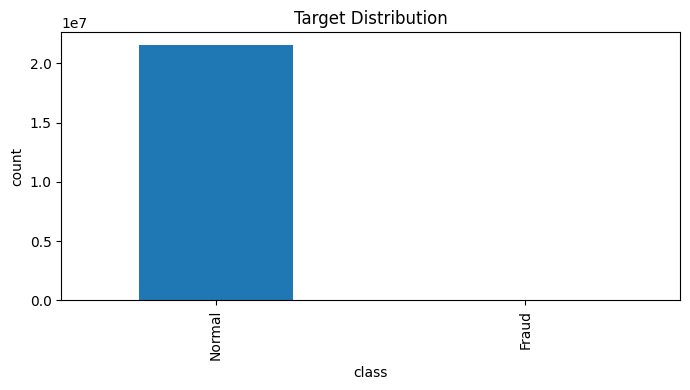

In [5]:
target_count = events['fraud_label'].value_counts(dropna=False).sort_index()
target_rate = events['fraud_label'].value_counts(normalize=True, dropna=False).sort_index().mul(100)

target_summary = pd.DataFrame({'count': target_count, 'percent': target_rate,})

display(target_summary)

fraud_rate = events['fraud_label'].eq(1).mean()

print('전체 Event:', f'{len(events):,}')
print('Fraud Event:', f'{int(events["fraud_label"].eq(1).sum()):,}')
print('Fraud Rate :', f'{fraud_rate:.6%}')

ax = (events['fraud_label'].map({0: 'Normal', 1: 'Fraud'}).value_counts().plot(kind='bar', figsize=(7, 4)))
ax.set_title('Target Distribution')
ax.set_xlabel('class')
ax.set_ylabel('count')
plt.tight_layout()
plt.show()


## 11. EDA — 거래 원천별 Fraud 비율

계좌거래(`transactions`)와 카드결제(`card_payments`)는 Fraud 발생 구조가 다를 수 있습니다.  
원천별 건수뿐 아니라 **Fraud Rate**를 함께 확인합니다.


,source_table,events,frauds,fraud_rate,customers,avg_amount,median_amount,fraud_rate_pct
0,card_payments,16887471,2493,0.000148,73739,1.128195e+05,88400.00,0.014762
1,transactions,4667747,113,0.000024,80000,1.786088e+06,1386427.74,0.002421


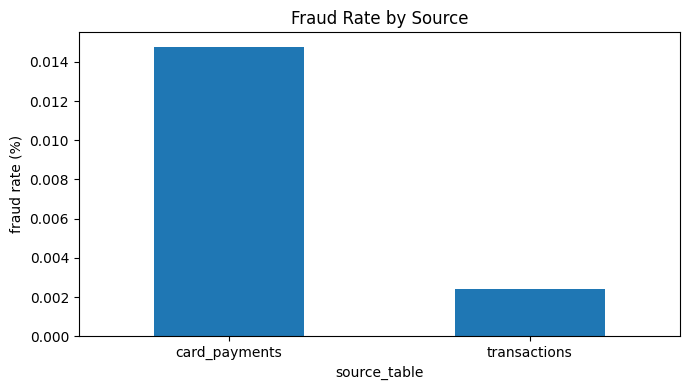

In [6]:
fraud_by_source = (events.groupby('source_table', observed=True).agg(events=('event_uid', 'size'), frauds=('fraud_label', 'sum'), fraud_rate=('fraud_label', 'mean'), customers=('customer_id', 'nunique'), avg_amount=('amount_abs', 'mean'), median_amount=('amount_abs', 'median')).reset_index())

fraud_by_source['fraud_rate_pct'] = fraud_by_source['fraud_rate'].mul(100)

display(fraud_by_source)

ax = fraud_by_source.plot(kind='bar', x='source_table', y='fraud_rate_pct', figsize=(7, 4), legend=False)
ax.set_title('Fraud Rate by Source')
ax.set_ylabel('fraud rate (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 12. EDA — Fraud 유형 구조

`fraud_type`은 모델 Target에는 직접 넣지 않지만, 어떤 Fraud 유형이 존재하고 모델이 무엇을 놓치면 안 되는지 이해하는 데 중요합니다.
| 영문 | 한국어 | 의미 |
|---|---|---|
| `CARD_NOT_PRESENT` | 비대면 카드 사기 | 실물 카드 없이 카드번호, 유효기간 등 카드정보를 탈취해 온라인 등에서 부정 결제하는 사기 |
| `COUNTERFEIT_CARD` | 위조 카드 사기 | 탈취한 카드정보를 이용해 가짜 카드를 만들어 부정 사용하는 사기 |
| `LOST_STOLEN_CARD` | 분실·도난 카드 부정사용 | 분실하거나 도난당한 실제 카드를 다른 사람이 부정 사용하는 경우 |
| `ACCOUNT_TAKEOVER` | 계정 탈취 사기 | 사용자의 금융·결제 계정을 탈취해 본인인 것처럼 부정 거래하는 사기 |
| `INSTITUTION_IMPERSONATION` | 기관 사칭 사기 | 금융기관, 수사기관, 공공기관 등을 사칭해 송금이나 개인정보 제공을 유도하는 사기 |
| `MESSENGER_PHISHING` | 메신저 피싱 | 가족이나 지인을 사칭해 메신저로 송금이나 개인정보 제공을 요구하는 사기 |
| `LOAN_IMPERSONATION` | 대출 사칭 사기 | 금융회사나 대출 담당자를 사칭해 수수료, 보증금 등의 명목으로 송금을 유도하는 사기 |

,source_table,fraud_type,fraud_events,fraud_amount,avg_amount,median_amount
1,card_payments,CARD_NOT_PRESENT,1443,"348,146,519.160000","241,265.779044","179,925.820000"
2,card_payments,COUNTERFEIT_CARD,498,"96,336,085.790000","193,445.955402","152,529.925000"
3,card_payments,LOST_STOLEN_CARD,425,"93,760,163.330000","220,612.149012","174,968.110000"
0,card_payments,ACCOUNT_TAKEOVER,127,"39,728,665.660000","312,824.139055","240,858.420000"
4,transactions,INSTITUTION_IMPERSONATION,38,"744,486,042.870000","19,591,737.970263","12,354,524.730000"
6,transactions,MESSENGER_PHISHING,38,"110,780,004.310000","2,915,263.271316","2,329,418.950000"
5,transactions,LOAN_IMPERSONATION,37,"345,841,023.470000","9,347,054.688378","6,784,946.300000"


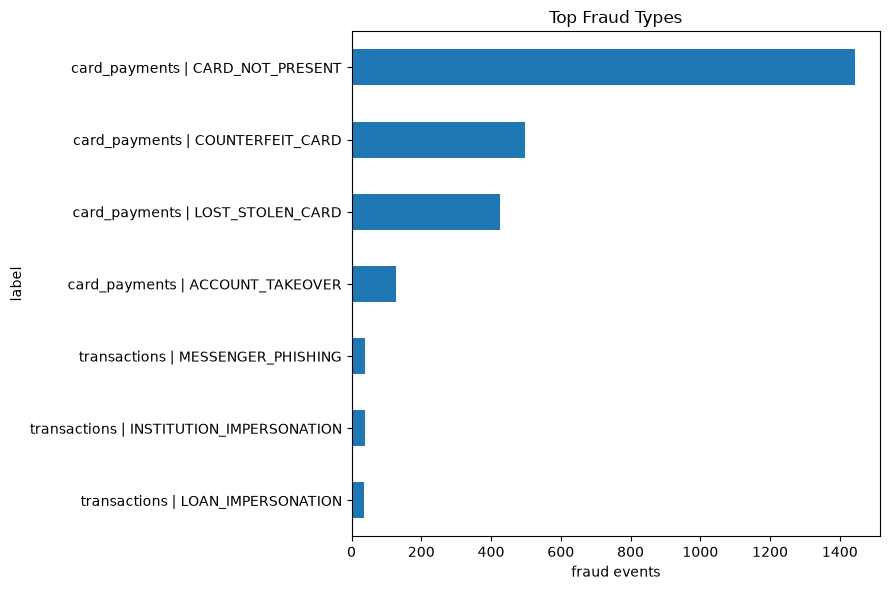

In [13]:
fraud_type_summary = (events.loc[events['fraud_label'].eq(1)].groupby(['source_table', 'fraud_type'], observed=True, dropna=False).agg(fraud_events=('event_uid', 'size'), fraud_amount=('amount_abs', 'sum'), avg_amount=('amount_abs', 'mean'), median_amount=('amount_abs', 'median')).reset_index().sort_values(['source_table', 'fraud_events'], ascending=[True, False]))

display(fraud_type_summary)

plot_fraud_type = (fraud_type_summary .assign(label=lambda x: x['source_table'].astype(str) + ' | ' + x['fraud_type'].astype(str)).nlargest(15, 'fraud_events').sort_values('fraud_events'))

ax = plot_fraud_type.plot(kind='barh', x='label', y='fraud_events', figsize=(9, 6), legend=False)
ax.set_title('Top Fraud Types')
ax.set_xlabel('fraud events')
plt.tight_layout()
plt.show()


## 13. EDA — 거래금액 분포와 Fraud / Normal 비교

금융거래 금액은 긴 꼬리(Long Tail)를 가지는 경우가 많습니다.  
원금액만 보면 일부 큰 거래가 그래프를 지배하므로 `log1p(amount_abs)`도 함께 확인합니다.

> 로그 변환은 모델에서 금액을 숨기는 것이 아니라, 큰 값의 영향력을 완화해 분포를 보기 쉽게 만드는 방법입니다.


,count,mean,median,std,max
fraud_label,,,,,
0,21552612,"475,138.020053","110,400.000000","1,055,979.083099","75,386,311.280000"
1,2606,"682,685.535146","182,392.130000","3,421,092.229663","60,735,608.160000"


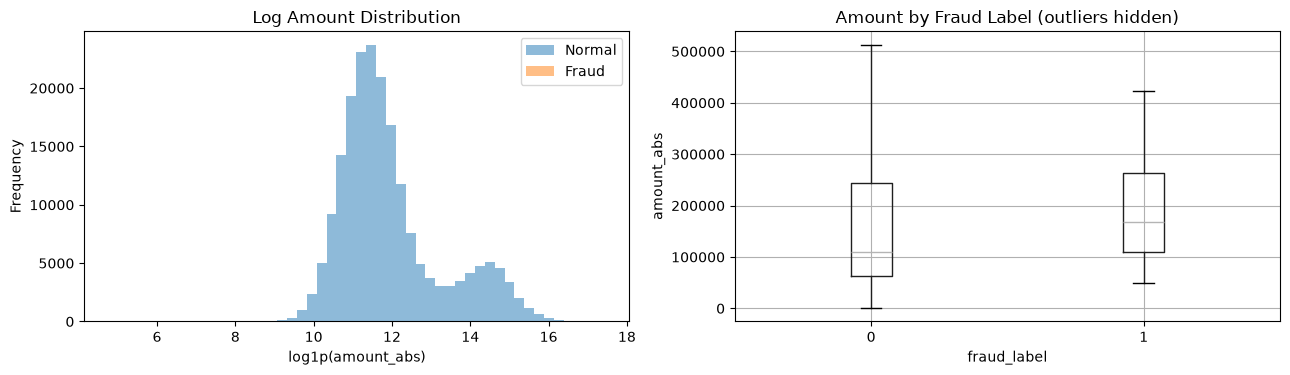

In [14]:
eda_plot = events[['amount_abs', 'fraud_label', 'source_table']].dropna().copy()

if len(eda_plot) > 200_000:
    eda_plot = eda_plot.sample(200_000, random_state=42)

eda_plot['log_amount'] = np.log1p(pd.to_numeric(eda_plot['amount_abs'], errors='coerce').clip(lower=0))

amount_stats = (events.groupby('fraud_label', observed=True)['amount_abs'].agg(['count', 'mean', 'median', 'std', 'max']))

display(amount_stats)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for label, group in eda_plot.groupby('fraud_label'):
    name = 'Fraud' if label == 1 else 'Normal'
    group['log_amount'].plot(kind='hist', bins=50, alpha=0.5, ax=axes[0], label=name)

axes[0].set_title('Log Amount Distribution')
axes[0].set_xlabel('log1p(amount_abs)')
axes[0].legend()

eda_plot.boxplot(column='amount_abs', by='fraud_label', ax=axes[1], showfliers=False)
axes[1].set_title('Amount by Fraud Label (outliers hidden)')
axes[1].set_xlabel('fraud_label')
axes[1].set_ylabel('amount_abs')

plt.suptitle('')
plt.tight_layout()
plt.show()


## 14. EDA — 범주형 변수별 Fraud Rate

단순 빈도보다 **각 범주에서 Fraud 비율이 얼마나 다른지** 보는 것이 중요합니다.

카테고리별 건수가 너무 작으면 Fraud Rate가 우연히 크게 보일 수 있으므로 `events` 건수도 함께 확인합니다.


In [15]:
def fraud_rate_by_category(data, column, min_count=100):
    if column not in data.columns:
        return pd.DataFrame()

    out = (data.groupby(column, observed=True, dropna=False).agg(events=('fraud_label', 'size'), frauds=('fraud_label', 'sum'), fraud_rate=('fraud_label', 'mean')).reset_index())

    out = out[out['events'] >= min_count].copy()
    out['fraud_rate_pct'] = out['fraud_rate'].mul(100)

    return out.sort_values(['fraud_rate', 'events'], ascending=[False, False])

for col in ['channel', 'risk_segment', 'merchant_risk_level', 'device_type', 'auth_method',]:
    result = fraud_rate_by_category(events, col, min_count=100)

    if len(result):
        print(f'\n[{col}]')
        display(result.head(15))



[channel]


,channel,events,frauds,fraud_rate,fraud_rate_pct
1,ECOMMERCE,2875624,1570,0.000546,0.054597
3,POS,14011847,923,0.000066,0.006587
2,MOBILE,3707714,113,0.000030,0.003048
0,API,960033,0,0.000000,0.000000



[risk_segment]


,risk_segment,events,frauds,fraud_rate,fraud_rate_pct
0,HIGH,284351,36,0.000127,0.012660
1,LOW,10693146,1299,0.000121,0.012148
2,MEDIUM,10577721,1271,0.000120,0.012016



[merchant_risk_level]


,merchant_risk_level,events,frauds,fraud_rate,fraud_rate_pct
1,MEDIUM,1704934,259,0.000152,0.015191
0,LOW,15182537,2234,0.000147,0.014714
2,NaN,4667747,113,0.000024,0.002421



[device_type]


,device_type,events,frauds,fraud_rate,fraud_rate_pct
3,NaN,5850445,2028,0.000347,0.034664
1,PC,1633757,61,0.000037,0.003734
0,MOBILE,13703787,506,0.000037,0.003692
2,TABLET,367229,11,0.000030,0.002995



[auth_method]


,auth_method,events,frauds,fraud_rate,fraud_rate_pct
3,TOKEN,4223235,1112,0.000263,0.026331
2,SIGNATURE,4220469,983,0.000233,0.023291
1,PIN,4222289,359,0.000085,0.008502
4,NaN,4667747,113,0.000024,0.002421
0,BIOMETRIC,4221478,39,0.000009,0.000924


## 15. EDA — 시간대별 Fraud 패턴

FDS에서는 거래가 **언제 발생했는가**도 중요한 Feature입니다.

현재 시점의 결과를 이용하지 않고 `event_at`에서 안전하게 만들 수 있는 `event_hour`, `day_of_week`, `is_weekend`, `is_night`를 확인합니다.


,events,frauds,fraud_rate
event_hour,,,
0,211380,0,0.000000
1,2,0,0.000000
2,1,0,0.000000
3,1,0,0.000000
5,3,0,0.000000
6,2,0,0.000000
8,1126740,171,0.000152
9,1125477,172,0.000153
10,5582264,172,0.000031


,events,frauds,fraud_rate
day_of_week,,,
0,3153252,379,0.000120
1,2775328,361,0.000130
2,3064196,357,0.000117
3,3142971,407,0.000129
4,3123795,358,0.000115
5,2851506,390,0.000137
6,3444170,354,0.000103


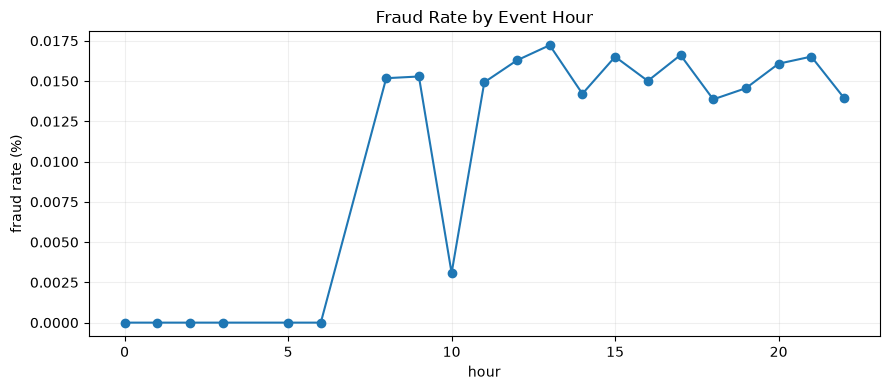

In [16]:
eda_time = events[['event_at', 'fraud_label']].dropna().copy()

eda_time['event_hour'] = eda_time['event_at'].dt.hour
eda_time['day_of_week'] = eda_time['event_at'].dt.dayofweek

hourly_fraud = (eda_time.groupby('event_hour', observed=True).agg(events=('fraud_label', 'size'), frauds=('fraud_label', 'sum'), fraud_rate=('fraud_label', 'mean')))

daily_fraud = (eda_time.groupby('day_of_week', observed=True).agg(events=('fraud_label', 'size'), frauds=('fraud_label', 'sum'), fraud_rate=('fraud_label', 'mean')))

display(hourly_fraud)
display(daily_fraud)

ax = hourly_fraud['fraud_rate'].mul(100).plot(figsize=(9, 4), marker='o')
ax.set_title('Fraud Rate by Event Hour')
ax.set_xlabel('hour')
ax.set_ylabel('fraud rate (%)')
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()


## 16. EDA — Fraud와 Normal의 주요 수치형 변수 비교

평균 하나만 보면 이상치의 영향을 많이 받을 수 있으므로 평균과 중앙값을 함께 봅니다.

여기서 차이가 보인다고 해서 곧바로 원인이라고 해석하면 안 됩니다.  
EDA는 **모델 후보 Feature를 찾기 위한 탐색 단계**입니다.


In [17]:
eda_numeric_candidates = ['amount_abs', 'amount_to_card_limit', 'amount_to_monthly_card_budget', 'beneficiary_risk_score', 'balance_drain_ratio', 'amount_to_monthly_income', 'credit_score', 'household_annual_income', 'dsr_income', 'debt_to_income', 'debt_to_asset',]

eda_numeric = [c for c in eda_numeric_candidates if c in events.columns]

numeric_group_stats = (events.groupby('fraud_label', observed=True)[eda_numeric].agg(['mean', 'median']))

display(numeric_group_stats.round(4))


amount_abs                amount_to_card_limit           \
                      mean         median                 mean   median   
fraud_label                                                               
0           475,138.020100 110,400.000000             0.007000 0.004500   
1           682,685.535100 182,392.130000             0.014500 0.008900   

            amount_to_monthly_card_budget          beneficiary_risk_score  \
                                     mean   median                   mean   
fraud_label                                                                 
0                                0.048900 0.036500               0.095000   
1                                0.102700 0.074400               0.847200   

                     balance_drain_ratio          amount_to_monthly_income  \
              median                mean   median                     mean   
fraud_label                                                                  
0           0.095000      604,979.270400 0.136900                 0.583100   
1           0.842500    1,380,403.475700 0.670600                 4.132700   

                     credit_score            household_annual_income  \
              median         mean     median                    mean   
fraud_label                                                            
0           0.468800   747.550300 749.000000       95,687,436.831700   
1           2.010500   748.585600 749.000000       97,441,139.600200   

                              dsr_income          debt_to_income           \
                       median       mean   median           mean   median   
fraud_label                                                                 
0           82,624,982.450000   0.087800 0.040300       1.157600 0.057900   
1           84,065,507.480000   0.087000 0.035700       1.140000 0.044200   

            debt_to_asset           
                     mean   median  
fraud_label                         
0                0.185600 0.024200  
1                0.184200 0.015300

## 17. EDA — 선택 수치형 변수와 Target의 상관관계

상관계수는 **선형적인 관계의 강도**를 보는 보조 지표입니다.  
Fraud처럼 비선형 패턴과 범주형 Feature가 중요한 문제에서는 상관계수가 낮아도 모델에 유용할 수 있습니다.


,corr_with_fraud
beneficiary_is_new,1.000000
beneficiary_risk_score,0.051061
country_mismatch,0.045112
is_new_device_event,0.022835
device_trusted,-0.022835
amount_to_card_limit,0.012346
is_online,0.009915
amount_abs,0.006958
event_hour,0.002164
balance_drain_ratio,-0.002122


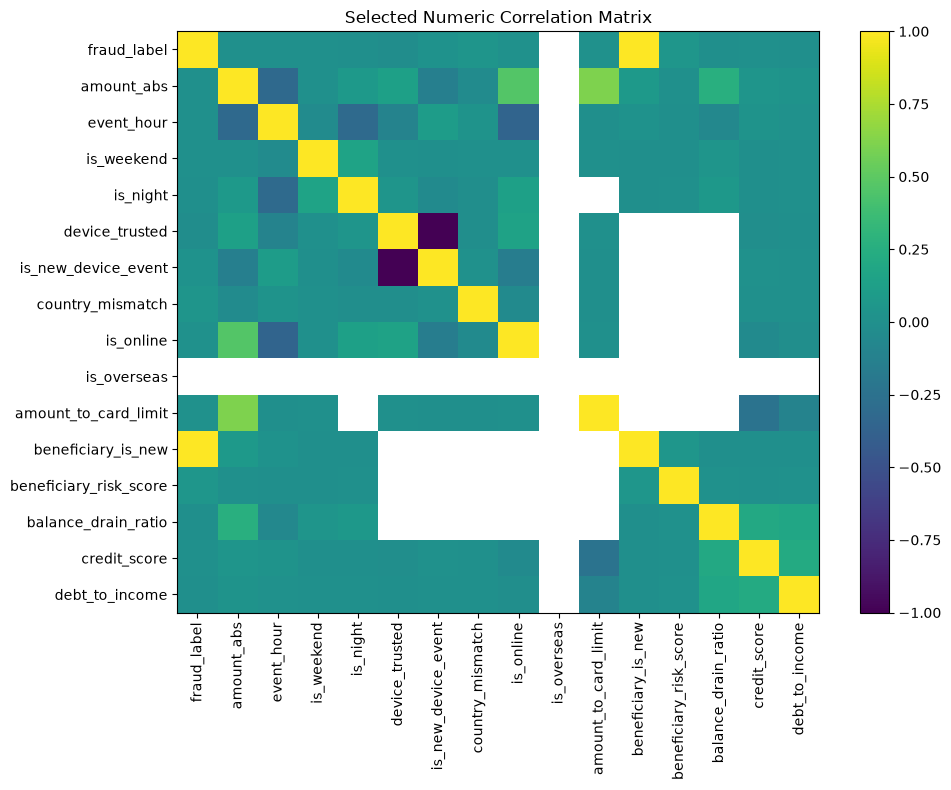

In [18]:
corr_candidates = ['fraud_label', 'amount_abs', 'event_hour', 'is_weekend', 'is_night', 'device_trusted', 'is_new_device_event', 'country_mismatch', 'is_online', 'is_overseas', 'amount_to_card_limit', 'beneficiary_is_new', 'beneficiary_risk_score', 'balance_drain_ratio', 'credit_score', 'debt_to_income',]

corr_cols = [c for c in corr_candidates if c in events.columns]

corr_source = events[corr_cols]

if len(corr_source) > 300_000:
    corr_source = corr_source.sample(300_000, random_state=42)

corr_df = corr_source.copy()

for col in corr_cols:
    corr_df[col] = pd.to_numeric(corr_df[col], errors='coerce')

corr = corr_df.corr()

display(corr['fraud_label'].drop('fraud_label').sort_values(key=lambda s: s.abs(), ascending=False).to_frame('corr_with_fraud'))

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr.to_numpy(), aspect='auto')

ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.index)))
ax.set_xticklabels(corr.columns, rotation=90)
ax.set_yticklabels(corr.index)
ax.set_title('Selected Numeric Correlation Matrix')

fig.colorbar(im)
plt.tight_layout()
plt.show()


## 18. EDA에서 확인한 내용을 모델 개발로 연결하기

EDA 이후 모델 개발에서는 다음 원칙을 사용합니다.

- Fraud가 희소하므로 **Accuracy 대신 PR-AUC / Recall / F2**를 중요하게 봅니다.
- 거래금액 자체뿐 아니라 **고객의 과거 평균 대비 현재 금액**, **짧은 시간 내 거래 횟수**, **신규 기기**, **신규 수취인** 같은 맥락 Feature가 필요합니다.
- 계좌이체와 카드결제는 사용할 수 있는 정보가 다르므로 Source-specific Feature를 유지합니다.
- 시간의 미래 정보를 사용하면 Data Leakage가 발생하므로 History Feature는 **현재 Event 이전의 과거 정보만** 사용합니다.
- 모델 후보를 여러 개 비교하되 최종 선택은 Test가 아니라 **Validation**에서 합니다.


## Part 1·2 종료 — 원천 DataFrame 메모리 정리

Feature Engineering에는 통합된 `events`만 필요합니다.  
원시 거래·결제와 Master DataFrame, EDA 임시 객체를 정리해 메모리를 확보합니다.


In [19]:
engine.dispose()

for _name in ['transactions', 'card_payments', 'customers', 'profiles', 'cards', 'merchants', 'devices', 'debt_summary', 'fraud_cases', 'fds_generation_summary', 'frames', 'local_frames', 'tx_events', 'card_events', 'params', 'connection_check', 'latest_dates', 'schema_check', 'contract_check', 'target_count', 'target_rate', 'target_summary', 'fraud_by_source', 'fraud_type_summary', 'plot_fraud_type', 'eda_plot', 'amount_stats', 'eda_time', 'hourly_fraud', 'daily_fraud', 'numeric_group_stats', 'corr_df', 'corr', 'source_missing', 'missing_summary',]:
    globals().pop(_name, None)

gc.collect()

event_memory_mb = (events.memory_usage(deep=True).sum() / 1024**2)

print('통합 Event:', f'{len(events):,} rows')
print('events 메모리 사용량:', f'{event_memory_mb:,.1f} MB')


통합 Event: 21,555,218 rows
events 메모리 사용량: 19,329.6 MB


# Part 3. Feature Engineering · Rule Baseline

EDA에서 확인한 단순 컬럼만으로는 고객마다 다른 정상 패턴을 충분히 표현하기 어렵습니다.

따라서 현재 Event보다 **이전에 발생한 거래만 사용하여** 고객별 History Feature를 만듭니다.

```text
현재 거래금액
+ 최근 10분 거래횟수
+ 최근 1시간 거래횟수/금액
+ 최근 24시간 거래횟수/금액
+ 최근 30일 평균/표준편차
+ 직전 거래 이후 경과시간
+ 신규기기 / 신규수취인 / 카드한도 대비 금액
```

이런 Feature는 "큰 금액인가?"보다 "이 고객에게 평소와 다른 거래인가?"를 표현하는 데 유리합니다.


## 19. Point-in-Time History Feature

현재 Event를 제외한 과거 정보만 사용합니다. 고객별 NumPy `searchsorted`와 prefix sum을 이용해 대용량에서도 반복 DataFrame filter를 피합니다.

In [20]:
def add_point_in_time_history_features(df):
    # 고객별로 과거 이력을 정확히 계산하기 위해 시간순으로 정렬
    df.sort_values(['customer_id', 'event_at', 'event_uid'], inplace=True)
    df.reset_index(drop=True, inplace=True)

    # 원본 복사 없이 같은 DataFrame을 사용해 메모리 절약
    work = df
    n = len(work)

    # 계산 결과를 저장할 NumPy 배열을 미리 생성해 반복 처리 속도 향상
    count_10m = np.zeros(n, dtype=np.int32)
    count_1h = np.zeros(n, dtype=np.int32)
    sum_1h = np.zeros(n, dtype=np.float64)
    count_24h = np.zeros(n, dtype=np.int32)
    sum_24h = np.zeros(n, dtype=np.float64)
    count_30d = np.zeros(n, dtype=np.int32)
    mean_30d = np.full(n, np.nan)
    std_30d = np.full(n, np.nan)
    minutes_prev = np.full(n, np.nan)

    # Timestamp와 비교할 수 있도록 시간 Window를 나노초 단위 정수로 변환
    W10 = int(pd.Timedelta(minutes=10).value)
    W1H = int(pd.Timedelta(hours=1).value)
    W24 = int(pd.Timedelta(hours=24).value)
    W30D = int(pd.Timedelta(days=30).value)

    # 전체 Feature 계산 시간 측정
    started = time.perf_counter()

    # 고객별로 거래 이력을 분리해 과거 데이터만 사용한 Feature 계산
    for _, pos in work.groupby('customer_id', sort=False).indices.items():
        pos = np.asarray(pos, dtype=np.int64)

        # 거래시간을 나노초 단위 정수 배열로 변환해 빠르게 비교
        times = work.iloc[pos]['event_at'].astype('int64').to_numpy()

        # 거래금액을 숫자형으로 변환하고 결측값은 누적합 계산을 위해 0 처리
        amounts = pd.to_numeric(
            work.iloc[pos]['amount_abs'],
            errors='coerce'
        ).fillna(0).to_numpy(float)

        # 각 거래의 현재 위치: [0, 1, 2, ...]
        right = np.arange(len(pos), dtype=np.int64)

        # 현재 시점 기준 10분, 1시간, 24시간, 30일 Window의 시작 위치 탐색
        left10 = np.searchsorted(times, times - W10, side='left')
        left1h = np.searchsorted(times, times - W1H, side='left')
        left24 = np.searchsorted(times, times - W24, side='left')
        left30 = np.searchsorted(times, times - W30D, side='left')

        # 누적합을 만들어 구간별 거래금액 합계를 빠르게 계산
        prefix = np.r_[0.0, np.cumsum(amounts)]

        # 표준편차 계산을 위해 거래금액 제곱의 누적합도 생성
        prefix_sq = np.r_[0.0, np.cumsum(amounts ** 2)]

        # 현재 거래를 제외한 최근 10분 과거 거래 횟수
        count_10m[pos] = right - left10

        # 현재 거래를 제외한 최근 1시간 거래 횟수와 금액 합계
        count_1h[pos] = right - left1h
        sum_1h[pos] = prefix[right] - prefix[left1h]

        # 현재 거래를 제외한 최근 24시간 거래 횟수와 금액 합계
        count_24h[pos] = right - left24
        sum_24h[pos] = prefix[right] - prefix[left24]

        # 최근 30일 거래 횟수, 금액 합계, 금액 제곱합
        c30 = right - left30
        s30 = prefix[right] - prefix[left30]
        sq30 = prefix_sq[right] - prefix_sq[left30]

        count_30d[pos] = c30

        # 과거 거래가 1건 이상일 때만 최근 30일 평균 계산
        valid_mean = c30 > 0
        m30 = np.full(len(pos), np.nan)
        m30[valid_mean] = s30[valid_mean] / c30[valid_mean]
        mean_30d[pos] = m30

        # 과거 거래가 2건 이상일 때만 표본 표준편차 계산
        valid_std = c30 > 1
        var = np.full(len(pos), np.nan)
        var[valid_std] = (
            sq30[valid_std] - (s30[valid_std] ** 2) / c30[valid_std]
        ) / (c30[valid_std] - 1)

        # 부동소수점 계산 오차로 생길 수 있는 음수 분산을 0으로 보정
        var = np.where(np.isnan(var), np.nan, np.maximum(var, 0))
        std_30d[pos] = np.sqrt(var)

        # 직전 거래 이후 경과시간을 나노초에서 분 단위로 변환
        if len(pos) > 1:
            minutes_prev[pos[1:]] = (
                times[1:] - times[:-1]
            ) / (60 * 1_000_000_000)

    # 계산한 NumPy 배열을 최종 Feature 컬럼으로 추가
    work['customer_event_count_10m'] = count_10m
    work['customer_event_count_1h'] = count_1h
    work['customer_amount_sum_1h'] = sum_1h
    work['customer_event_count_24h'] = count_24h
    work['customer_amount_sum_24h'] = sum_24h
    work['customer_event_count_30d'] = count_30d
    work['customer_amount_mean_30d'] = mean_30d
    work['customer_amount_std_30d'] = std_30d
    work['minutes_since_prev_event'] = minutes_prev

    # 현재 거래금액이 최근 30일 평균 거래금액의 몇 배인지 계산
    work['amount_vs_customer_mean_30d'] = np.where(
        work['customer_amount_mean_30d'].gt(0),
        work['amount_abs'] / work['customer_amount_mean_30d'],
        np.nan
    )

    # 현재 거래금액이 최근 30일 평균에서 표준편차 기준 얼마나 벗어났는지 계산
    work['amount_zscore_30d'] = np.where(
        work['customer_amount_std_30d'].gt(0),
        (work['amount_abs'] - work['customer_amount_mean_30d'])
        / work['customer_amount_std_30d'],
        np.nan
    )

    # 최근 30일 과거 거래가 3건 이상이면 이력 정보가 충분하다고 표시
    work['customer_history_available'] = (
        work['customer_event_count_30d'] >= 3
    ).astype(int)

    print('Point-in-Time Feature 완료:', f'{time.perf_counter() - started:,.1f}초')

    return work


# 현재 시점 이전의 과거 거래만 이용한 이력 Feature 생성
fds_features = add_point_in_time_history_features(events)

# 더 이상 사용하지 않는 변수 제거 후 메모리 정리
del events
gc.collect()

# 주요 Point-in-Time Feature 결과 확인
display(
    fds_features[
        [
            'customer_id',
            'event_at',
            'amount_abs',
            'customer_event_count_10m',
            'customer_event_count_1h',
            'customer_amount_sum_1h',
            'customer_event_count_24h',
            'customer_amount_mean_30d',
            'amount_zscore_30d',
            'minutes_since_prev_event',
        ]
    ].head(20)
)

Point-in-Time Feature 완료: 202.3초


,customer_id,event_at,amount_abs,customer_event_count_10m,customer_event_count_1h,customer_amount_sum_1h,customer_event_count_24h,customer_amount_mean_30d,amount_zscore_30d,minutes_since_prev_event
0,1,2025-09-14 14:37:00,"124,000.000000",0,0,0.000000,0,NaN,NaN,NaN
1,1,2025-09-15 10:00:00,"3,606,244.420000",1,1,"124,000.000000",1,"124,000.000000",NaN,1.163000
2,1,2025-09-15 20:25:00,"256,900.000000",2,2,"3,730,244.420000",2,"1,865,122.210000",-0.653133,0.625000
3,1,2025-09-15 22:03:00,"39,900.000000",3,3,"3,987,144.420000",3,"1,329,048.140000",-0.653319,0.098000
4,1,2025-09-17 16:50:00,"93,000.000000",4,4,"4,027,044.420000",4,"1,006,761.105000",-0.526575,2.567000
5,1,2025-09-17 20:14:00,"140,000.000000",5,5,"4,120,044.420000",5,"824,008.884000",-0.439206,0.204000
6,1,2025-09-19 10:00:00,"1,554,042.860000",6,6,"4,260,044.420000",6,"710,007.403333",0.594110,2.266000
7,1,2025-09-20 13:47:00,"84,600.000000",7,7,"5,814,087.280000",7,"830,583.897143",-0.558559,1.667000
8,1,2025-09-21 09:13:00,"54,200.000000",8,8,"5,898,687.280000",8,"737,335.910000",-0.540329,1.166000
9,1,2025-09-21 17:52:00,"140,100.000000",8,9,"5,952,887.280000",9,"661,431.920000",-0.432869,0.519000


## 20. Source-specific FDS Feature 정리

계좌이체는 신규 수취인·위험수취인·잔액소진율·자금집중을, 카드결제는 카드한도·온라인·해외IP·신규기기를 사용합니다.

In [21]:
for col in ['device_trusted','is_new_device_event','country_mismatch','is_online','is_overseas', 'amount_to_card_limit','amount_to_monthly_card_budget','amount_vs_merchant_avg', 'beneficiary_is_new','beneficiary_risk_score','balance_drain_ratio', 'amount_to_monthly_income','funds_consolidation_24h','credit_score', 'household_annual_income','monthly_card_budget','financial_assets_estimated', 'dsr_income','debt_to_income','debt_to_asset',]:
    if col in fds_features.columns:
        fds_features[col] = pd.to_numeric(fds_features[col], errors='coerce')

fds_features['foreign_ip_flag'] = fds_features['ip_country'].fillna('KR').ne('KR').astype(int)
fds_features['source_is_transfer'] = (fds_features['source_table'] == 'transactions').astype(int)
fds_features['source_is_card'] = (fds_features['source_table'] == 'card_payments').astype(int)

display(fds_features[['source_table','amount_abs','is_new_device_event','foreign_ip_flag', 'beneficiary_is_new','beneficiary_risk_score','balance_drain_ratio', 'funds_consolidation_24h','amount_to_card_limit','fraud_label','fraud_type']].sample(min(20, len(fds_features)), random_state=42))

,source_table,amount_abs,is_new_device_event,foreign_ip_flag,beneficiary_is_new,beneficiary_risk_score,balance_drain_ratio,funds_consolidation_24h,amount_to_card_limit,fraud_label,fraud_type
8821387,card_payments,"70,000.000000",1,0,NaN,NaN,NaN,NaN,0.001520,0,NONE
4614999,card_payments,"227,800.000000",0,0,NaN,NaN,NaN,NaN,0.007101,0,NONE
13131288,transactions,"1,033,364.150000",0,0,0.000000,0.048200,"1,033,364.147392",0.000000,NaN,0,NONE
10571086,card_payments,"142,800.000000",0,0,NaN,NaN,NaN,NaN,0.009106,0,NONE
19724777,transactions,"327,379.680000",0,0,0.000000,0.090600,"327,379.683603",0.000000,NaN,0,NONE
6772578,card_payments,"185,400.000000",0,0,NaN,NaN,NaN,NaN,0.007597,0,NONE
33877,card_payments,"233,300.000000",0,0,NaN,NaN,NaN,NaN,0.011536,0,NONE
16312103,card_payments,"39,000.000000",0,0,NaN,NaN,NaN,NaN,0.003867,0,NONE
13446355,card_payments,"123,400.000000",0,0,NaN,NaN,NaN,NaN,0.002756,0,NONE
5651704,transactions,"371,415.130000",0,0,0.000000,0.030100,"371,415.130629",0.000000,NaN,0,NONE


## 21. 독립 Rule Baseline

생성기의 `fraud_score_simulated`와 내부 Rule 결과를 사용하지 않고 수업용 Rule Engine을 새로 정의합니다.

## RULE_CONFIG 항목 설명

`RULE_CONFIG`는 각 FDS Rule이 발동하는 기준값(Threshold)을 한곳에 모아둔 설정값입니다.  
Rule 코드에서는 이 값을 불러와 실제 거래가 조건을 만족하는지 판단합니다.

| RULE_CONFIG 항목 | 기준값 | 연결 Rule | 의미 |
|---|---:|---|---|
| `large_amount_zscore` | 4.0 | `R01_AMOUNT_ANOMALY` | 현재 거래금액이 최근 30일 평균보다 4 표준편차 이상 큰 경우 |
| `large_amount_min` | 500,000 | `R01_AMOUNT_ANOMALY` | 최소 50만 원 이상의 거래만 고액 이상 거래 후보로 판단 |
| `velocity_10m_count` | 3 | `R02_VELOCITY_10M` | 최근 10분 동안 과거 거래가 3건 이상 발생한 경우 |
| `velocity_1h_sum` | 10,000,000 | `R03_HIGH_SUM_1H` | 최근 1시간 과거 거래금액 + 현재 거래금액이 1,000만 원 이상인 경우 |
| `new_device_amount` | 2,000,000 | `R04_NEW_DEVICE_HIGH_AMOUNT` | 신규 기기에서 200만 원 이상의 거래가 발생한 경우 |
| `new_beneficiary_amount` | 3,000,000 | `R06_NEW_BENEFICIARY` | 신규 수취인에게 300만 원 이상 송금한 경우 |
| `beneficiary_risk` | 0.70 | `R07_RISKY_BENEFICIARY` | 수취인 위험점수가 0.70 이상인 경우 |
| `balance_drain_ratio` | 0.50 | `R08_BALANCE_DRAIN` | 거래로 인해 계좌 잔액의 50% 이상이 빠져나가는 경우 |
| `card_limit_ratio` | 0.50 | `R10_CARD_LIMIT` | 결제금액이 카드 한도의 50% 이상인 경우 |

> `R05_CARD_REMOTE_RISK`, `R09_FUND_CONSOLIDATION`은 별도의 숫자 임계값을 사용하지 않고, 이미 생성된 Boolean/Flag Feature를 직접 판단합니다.

In [22]:
# 각 FDS Rule에서 사용할 기준값(Threshold)을 한곳에 정의
RULE_CONFIG = {
    'large_amount_zscore': 4.0,          # R01: 최근 30일 평균보다 4 표준편차 이상 큰 거래
    'large_amount_min': 500_000,         # R01: 최소 50만 원 이상의 거래만 고액 이상치로 판단
    'velocity_10m_count': 3,             # R02: 최근 10분 과거 거래가 3건 이상이면 빈도 이상 탐지
    'velocity_1h_sum': 10_000_000,       # R03: 최근 1시간 누적금액 + 현재 거래가 1,000만 원 이상
    'new_device_amount': 2_000_000,      # R04: 신규 기기에서 200만 원 이상 거래
    'new_beneficiary_amount': 3_000_000, # R06: 신규 수취인에게 300만 원 이상 송금
    'beneficiary_risk': 0.70,            # R07: 수취인 위험점수가 0.70 이상
    'balance_drain_ratio': 0.50,         # R08: 계좌 잔액의 50% 이상이 빠져나가는 거래
    'card_limit_ratio': 0.50,            # R10: 카드 한도의 50% 이상을 한 번에 결제
}

# 설정된 Rule 기준값을 보기 쉬운 표 형태로 출력
display(
    pd.DataFrame(
        RULE_CONFIG.items(),
        columns=['rule_parameter', 'threshold']
    )
)

,rule_parameter,threshold
0,large_amount_zscore,4.000000
1,large_amount_min,"500,000.000000"
2,velocity_10m_count,3.000000
3,velocity_1h_sum,"10,000,000.000000"
4,new_device_amount,"2,000,000.000000"
5,new_beneficiary_amount,"3,000,000.000000"
6,beneficiary_risk,0.700000
7,balance_drain_ratio,0.500000
8,card_limit_ratio,0.500000


## FDS Rule-Based 탐지 규칙

Rule-Based FDS는 거래 금액, 거래 빈도, 신규 기기, 수취인 위험도, 카드 한도 등의 조건을 기준으로 이상 거래를 탐지합니다.

| Rule ID | Rule Name | 의미 | 주요 조건 | 점수 |
|---|---|---|---|---:|
| `R01` | `AMOUNT_ANOMALY` | 평소보다 비정상적으로 큰 금액의 거래 | 최근 30일 Z-score가 기준 이상이고 거래금액도 최소 금액 이상 | 12 |
| `R02` | `VELOCITY_10M` | 짧은 시간에 거래가 지나치게 많이 발생 | 최근 10분 거래 횟수가 기준 이상 | 10 |
| `R03` | `HIGH_SUM_1H` | 1시간 동안 거래금액이 과도하게 큼 | 최근 1시간 누적금액 + 현재 거래금액이 기준 이상 | 10 |
| `R04` | `NEW_DEVICE_HIGH_AMOUNT` | 새로운 기기에서 고액 거래 발생 | 신규 기기이면서 거래금액이 기준 이상 | 10 |
| `R05` | `CARD_REMOTE_RISK` | 비대면 카드 거래에서 접속 환경이 위험 | 카드 온라인 거래이면서 해외 IP 또는 신규 기기 사용 | 12 |
| `R06` | `NEW_BENEFICIARY` | 신규 수취인에게 고액 송금 | 계좌이체이면서 신규 수취인이고 송금액이 기준 이상 | 15 |
| `R07` | `RISKY_BENEFICIARY` | 위험도가 높은 수취인에게 송금 | 계좌이체이며 수취인 위험점수가 기준 이상 | 17 |
| `R08` | `BALANCE_DRAIN` | 계좌 잔액 대부분을 한 번에 송금 | 계좌이체이며 잔액 소진 비율이 기준 이상 | 12 |
| `R09` | `FUND_CONSOLIDATION` | 여러 자금을 짧은 시간에 한곳으로 모으는 패턴 | 계좌이체이며 최근 24시간 자금집중 패턴 발생 | 14 |
| `R10` | `CARD_LIMIT` | 카드 한도 대비 지나치게 큰 결제 | 카드 결제이며 결제금액/카드한도 비율이 기준 이상 | 10 |

### Rule Score 계산

각 거래에 대해 충족된 Rule의 점수를 합산합니다.

- `rule_count` : 탐지된 Rule 개수
- `rule_score` : 탐지된 Rule의 가중치 합계
- `triggered_rules` : 실제로 탐지된 Rule 목록
- `rule_severity` : 최종 Rule Score에 따른 위험 등급

| Rule Score | Severity | 의미 |
|---:|---|---|
| 0 | `NONE` | 탐지된 Rule 없음 |
| 1 ~ 19 | `LOW` | 낮은 위험 |
| 20 ~ 39 | `MEDIUM` | 중간 위험 |
| 40 ~ 59 | `HIGH` | 높은 위험 |
| 60 ~ 100 | `CRITICAL` | 매우 높은 위험 |

> 여러 Rule이 동시에 탐지될수록 `rule_count`와 `rule_score`가 증가하며, 최종 점수는 최대 100점으로 제한합니다.

In [23]:
# -----------------------------------------------------------------------------
# FDS Rule 조건 생성
# yield를 사용해 Rule Mask를 한 번에 하나씩 생성하여 메모리 사용을 줄임
# -----------------------------------------------------------------------------
def iter_rule_masks(df):

    # R01: 최근 30일 평균 대비 비정상적인 고액 거래
    yield ('R01_AMOUNT_ANOMALY', df['amount_zscore_30d'].ge(RULE_CONFIG['large_amount_zscore']) & df['amount_abs'].ge(RULE_CONFIG['large_amount_min']))

    # R02: 최근 10분 동안 거래 횟수가 기준 이상
    yield ('R02_VELOCITY_10M', df['customer_event_count_10m'].ge(RULE_CONFIG['velocity_10m_count']))

    # R03: 최근 1시간 누적 거래금액 + 현재 거래금액이 기준 이상
    yield ('R03_HIGH_SUM_1H', df['customer_amount_sum_1h'].add(df['amount_abs'], fill_value=0).ge(RULE_CONFIG['velocity_1h_sum']))

    # R04: 신규 기기에서 고액 거래 발생
    yield ('R04_NEW_DEVICE_HIGH_AMOUNT', df['is_new_device_event'].fillna(0).eq(1) & df['amount_abs'].ge(RULE_CONFIG['new_device_amount']))

    # R05: 온라인 카드 거래에서 해외 IP 또는 신규 기기 사용
    yield ('R05_CARD_REMOTE_RISK', df['source_is_card'].eq(1) & df['is_online'].fillna(0).eq(1) & (df['foreign_ip_flag'].eq(1) | df['is_new_device_event'].fillna(0).eq(1)))

    # R06: 신규 수취인에게 고액 송금
    yield ('R06_NEW_BENEFICIARY', df['source_is_transfer'].eq(1) & df['beneficiary_is_new'].fillna(0).eq(1) & df['amount_abs'].ge(RULE_CONFIG['new_beneficiary_amount']))

    # R07: 위험도가 높은 수취인에게 송금
    yield ('R07_RISKY_BENEFICIARY', df['source_is_transfer'].eq(1) & df['beneficiary_risk_score'].fillna(0).ge(RULE_CONFIG['beneficiary_risk']))

    # R08: 계좌 잔액 대부분을 한 번에 송금
    yield ('R08_BALANCE_DRAIN', df['source_is_transfer'].eq(1) & df['balance_drain_ratio'].fillna(0).ge(RULE_CONFIG['balance_drain_ratio']))

    # R09: 최근 24시간 동안 자금을 한곳으로 모으는 패턴
    yield ('R09_FUND_CONSOLIDATION', df['source_is_transfer'].eq(1) & df['funds_consolidation_24h'].fillna(0).eq(1))

    # R10: 카드 한도 대비 높은 금액의 결제
    yield ('R10_CARD_LIMIT', df['source_is_card'].eq(1) & df['amount_to_card_limit'].fillna(0).ge(RULE_CONFIG['card_limit_ratio']))


# Rule별 위험 가중치
RULE_WEIGHTS = {
    'R01_AMOUNT_ANOMALY': 12, 'R02_VELOCITY_10M': 10, 'R03_HIGH_SUM_1H': 10,
    'R04_NEW_DEVICE_HIGH_AMOUNT': 10, 'R05_CARD_REMOTE_RISK': 12,
    'R06_NEW_BENEFICIARY': 15, 'R07_RISKY_BENEFICIARY': 17,
    'R08_BALANCE_DRAIN': 12, 'R09_FUND_CONSOLIDATION': 14, 'R10_CARD_LIMIT': 10,
}

# 거래별 Rule 결과를 저장할 배열 생성
n = len(fds_features)
rule_count = np.zeros(n, dtype=np.int16)      # 탐지된 Rule 개수
rule_score = np.zeros(n, dtype=np.float32)    # Rule 가중치 합계
triggered = np.full(n, '', dtype=object)      # 탐지된 Rule 이름


# -----------------------------------------------------------------------------
# 각 Rule을 순서대로 적용
# -----------------------------------------------------------------------------
for name, mask_series in iter_rule_masks(fds_features):

    # 결측값은 미탐지(False)로 처리 후 NumPy Boolean 배열로 변환
    hit = mask_series.fillna(False).to_numpy()

    # Rule이 탐지된 거래의 개수와 위험점수 누적
    rule_count += hit.astype(np.int16)
    rule_score += hit * RULE_WEIGHTS[name]

    # 탐지된 행에 Rule 이름 기록, 여러 개면 |로 연결
    for i in np.flatnonzero(hit):
        triggered[i] = name if triggered[i] == '' else triggered[i] + '|' + name

    # 현재 Rule 계산에 사용한 임시 객체 삭제
    del mask_series, hit


# 계산 결과를 Feature DataFrame에 추가
fds_features['rule_count'] = rule_count
fds_features['rule_score'] = np.clip(rule_score, 0, 100)   # 최대 100점으로 제한

# Rule Score에 따라 위험 등급 분류
fds_features['rule_severity'] = pd.cut(
    fds_features['rule_score'], bins=[-1, 0, 19, 39, 59, 100],
    labels=['NONE', 'LOW', 'MEDIUM', 'HIGH', 'CRITICAL']
)

# 실제 탐지된 Rule 목록 저장
fds_features['triggered_rules'] = triggered

# 임시 배열 삭제 후 메모리 정리
del rule_count, rule_score, triggered
gc.collect()

# Rule Score가 높은 거래부터 확인
display(
    fds_features[['event_uid', 'source_table', 'amount_abs', 'rule_count', 'rule_score',
                  'rule_severity', 'triggered_rules', 'fraud_label', 'fraud_type']]
    .sort_values('rule_score', ascending=False).head(30)
)

,event_uid,source_table,amount_abs,rule_count,rule_score,rule_severity,triggered_rules,fraud_label,fraud_type
16843078,transactions:5224352,transactions,"26,688,115.960000",8,100.000000,CRITICAL,R01_AMOUNT_ANOMALY|R02_VELOCITY_10M|R03_HIGH_S...,1,INSTITUTION_IMPERSONATION
11971758,transactions:3715476,transactions,"52,657,435.240000",8,100.000000,CRITICAL,R01_AMOUNT_ANOMALY|R02_VELOCITY_10M|R03_HIGH_S...,1,INSTITUTION_IMPERSONATION
10747701,transactions:3335640,transactions,"44,214,793.350000",8,100.000000,CRITICAL,R01_AMOUNT_ANOMALY|R02_VELOCITY_10M|R03_HIGH_S...,1,INSTITUTION_IMPERSONATION
8863200,transactions:2751626,transactions,"34,890,391.570000",8,100.000000,CRITICAL,R01_AMOUNT_ANOMALY|R02_VELOCITY_10M|R03_HIGH_S...,1,INSTITUTION_IMPERSONATION
19554459,transactions:6063591,transactions,"5,083,511.110000",8,100.000000,CRITICAL,R01_AMOUNT_ANOMALY|R02_VELOCITY_10M|R03_HIGH_S...,1,LOAN_IMPERSONATION
16843077,transactions:5224351,transactions,"28,737,722.810000",8,100.000000,CRITICAL,R01_AMOUNT_ANOMALY|R02_VELOCITY_10M|R03_HIGH_S...,1,INSTITUTION_IMPERSONATION
19024839,transactions:5898220,transactions,"57,126,335.320000",8,100.000000,CRITICAL,R01_AMOUNT_ANOMALY|R02_VELOCITY_10M|R03_HIGH_S...,1,INSTITUTION_IMPERSONATION
7175497,transactions:2229761,transactions,"39,147,824.500000",8,100.000000,CRITICAL,R01_AMOUNT_ANOMALY|R02_VELOCITY_10M|R03_HIGH_S...,1,INSTITUTION_IMPERSONATION
7643213,transactions:2373024,transactions,"6,674,303.840000",8,100.000000,CRITICAL,R01_AMOUNT_ANOMALY|R02_VELOCITY_10M|R03_HIGH_S...,1,INSTITUTION_IMPERSONATION
7643214,transactions:2373025,transactions,"4,447,429.740000",8,100.000000,CRITICAL,R01_AMOUNT_ANOMALY|R02_VELOCITY_10M|R03_HIGH_S...,1,INSTITUTION_IMPERSONATION


## 22. Rule Threshold 탐색 — 탐색용 Baseline

먼저 Rule Engine만 사용할 때 Threshold에 따라 Precision / Recall / F2가 어떻게 바뀌는지 확인합니다.

이 단계의 값은 **Rule의 동작을 이해하기 위한 탐색용**입니다.  
최종 Rule Threshold는 뒤에서 ML과 동일하게 **Validation 데이터만 사용하여 다시 선택**합니다.


In [24]:
# 실제 정상(0) / 사기(1) 라벨이 있는 데이터만 Rule 성능 평가에 사용
rule_eval = fds_features[fds_features['fraud_label'].isin([0, 1])].copy()

# 실제 정답 라벨을 정수형 NumPy 배열로 변환
y_true = rule_eval['fraud_label'].astype(int).to_numpy()

# Threshold별 평가 결과를 저장할 리스트
rows = []

# Rule Score 기준을 5점부터 100점까지 5점 간격으로 변경하며 성능 비교
for threshold in range(5, 101, 5):

    # Rule Score가 Threshold 이상이면 사기(1), 아니면 정상(0)으로 예측
    pred = rule_eval['rule_score'].ge(threshold).astype(int).to_numpy()

    # Threshold별 Alert 비율과 분류 성능 지표 저장
    rows.append({
        'threshold': threshold,
        'alert_rate': float(pred.mean()),   # 전체 거래 중 경고가 발생한 비율
        'precision': precision_score(y_true, pred, zero_division=0),  # 탐지한 것 중 실제 사기 비율
        'recall': recall_score(y_true, pred, zero_division=0),        # 실제 사기 중 탐지한 비율
        'f1': f1_score(y_true, pred, zero_division=0),                # Precision과 Recall의 균형
        'f2': fbeta_score(y_true, pred, beta=2, zero_division=0),     # Recall에 더 큰 비중을 둔 점수
    })

# Threshold별 평가 결과를 DataFrame으로 변환
rule_threshold_eval = pd.DataFrame(rows)

# F2가 가장 높고, 동률이면 Recall이 높은 Threshold를 탐색용 기준으로 선택
exploratory_best_rule = rule_threshold_eval.sort_values(['f2', 'recall'], ascending=False).iloc[0]

# 탐색 단계에서 사용할 최적 Rule Score Threshold 저장
EXPLORATORY_RULE_THRESHOLD = float(exploratory_best_rule['threshold'])

# 전체 Threshold 평가 결과와 선택된 최적 결과 확인
display(rule_threshold_eval)
display(exploratory_best_rule.to_frame('value'))

print('탐색용 Rule Threshold:', EXPLORATORY_RULE_THRESHOLD)
print('최종 Rule Threshold는 Part 5의 Validation에서 다시 선택합니다.')

,threshold,alert_rate,precision,recall,f1,f2
0,5,0.937486,0.000126,0.978127,0.000252,0.000630
1,10,0.937486,0.000126,0.978127,0.000252,0.000630
2,15,0.738661,0.000142,0.865311,0.000283,0.000708
3,20,0.738661,0.000142,0.865311,0.000283,0.000708
4,25,0.090342,0.000588,0.439371,0.001174,0.002924
5,30,0.090342,0.000586,0.438219,0.001171,0.002917
6,35,0.001829,0.002791,0.042210,0.005235,0.011035
7,40,0.001828,0.002664,0.040292,0.004998,0.010535
8,45,0.000006,0.816000,0.039140,0.074698,0.048346
9,50,0.000005,1.000000,0.039140,0.075332,0.048451


,value
threshold,50.000000
alert_rate,0.000005
precision,1.000000
recall,0.039140
f1,0.075332
f2,0.048451


탐색용 Rule Threshold: 50.0
최종 Rule Threshold는 Part 5의 Validation에서 다시 선택합니다.


## 23. ML Feature 계약

Target, 사후결과, 생성기 내부 FDS 점수, 앞 단계 Rule 결과는 ML 입력에서 제외합니다.

In [25]:
NUMERIC_FEATURES = ['amount_abs','event_hour','day_of_week','is_weekend','is_night', 'device_trusted','is_new_device_event','foreign_ip_flag','country_mismatch', 'is_online','is_overseas','amount_to_card_limit','amount_to_monthly_card_budget', 'amount_vs_merchant_avg','device_age_days','beneficiary_is_new', 'beneficiary_risk_score','balance_drain_ratio','amount_to_monthly_income', 'funds_consolidation_24h','customer_event_count_10m','customer_event_count_1h', 'customer_amount_sum_1h','customer_event_count_24h','customer_amount_sum_24h', 'customer_event_count_30d','customer_amount_mean_30d','customer_amount_std_30d', 'amount_vs_customer_mean_30d','amount_zscore_30d','minutes_since_prev_event', 'customer_history_available','credit_score','household_annual_income', 'monthly_card_budget','financial_assets_estimated','dsr_income','debt_to_income', 'debt_to_asset','high_debt_service_flag','high_fixed_burden_flag',]
CATEGORICAL_FEATURES = ['source_table','event_subtype','channel','auth_method','ip_country', 'risk_segment','income_band','occupation','age_band','employment_type', 'merchant_category','merchant_risk_level','card_type','device_type',]
NUMERIC_FEATURES = [c for c in NUMERIC_FEATURES if c in fds_features.columns]
CATEGORICAL_FEATURES = [c for c in CATEGORICAL_FEATURES if c in fds_features.columns]
MODEL_FEATURES = NUMERIC_FEATURES + CATEGORICAL_FEATURES

LEAKAGE_COLUMNS = ['fraud_label','fraud_type','fraud_case_id','fraud_score_simulated', 'response_code','is_approved','fraud_prevented_flag','chargeback_reported_at', 'transaction_status','fraud_mechanism','fds_rule_count','fds_rule_foreign_ip', 'fds_rule_new_device','fds_rule_high_amount','fds_rule_online_highrisk', 'is_suspicious_rule_flag','rule_score','rule_count','triggered_rules',]

print('Numeric:', len(NUMERIC_FEATURES))
print('Categorical:', len(CATEGORICAL_FEATURES))
print('Total:', len(MODEL_FEATURES))
display(fds_features[MODEL_FEATURES].isna().mean().mul(100).sort_values(ascending=False).rename_axis('feature').reset_index(name='missing_pct').head(30))

Numeric: 41
Categorical: 14
Total: 55


,feature,missing_pct
0,beneficiary_risk_score,78.345164
1,balance_drain_ratio,78.345164
2,beneficiary_is_new,78.345164
3,funds_consolidation_24h,78.345164
4,amount_to_monthly_income,78.345164
5,device_age_days,27.141665
6,device_type,27.141665
7,amount_to_monthly_card_budget,21.654836
8,amount_vs_merchant_avg,21.654836
9,merchant_category,21.654836


## 24. 모델링용 Feature Mart 구성

Target, 식별용 컬럼, Rule 결과 등은 평가용으로 남기되 ML 입력에는 넣지 않습니다.

여기까지의 `model_df`가 이후 Machine Learning 단계의 개발 데이터가 됩니다.


In [26]:
EVALUATION_COLUMNS = ['event_uid', 'event_at', 'customer_id', 'fraud_label', 'fraud_type', 'fraud_case_id', 'rule_score', 'rule_severity',]

HANDOFF_COLUMNS = list(dict.fromkeys(EVALUATION_COLUMNS + MODEL_FEATURES))

HANDOFF_COLUMNS = [c for c in HANDOFF_COLUMNS if c in fds_features.columns]

model_df = (fds_features[HANDOFF_COLUMNS].loc[lambda x: x['fraud_label'].isin([0, 1]) & x['event_at'].notna()].sort_values(['event_at', 'event_uid']).reset_index(drop=True).copy())

model_df['fraud_label'] = (model_df['fraud_label'].astype(np.int8))

del fds_features
gc.collect()

model_memory_mb = (model_df .memory_usage(deep=True).sum() / 1024**2)

print('03 전달 Rows:', f'{len(model_df):,}')
print('Frauds:', f'{int(model_df["fraud_label"].sum()):,}')
print('Fraud rate:', f'{model_df["fraud_label"].mean():.6%}')
print('Features:', len(MODEL_FEATURES))
print('model_df 메모리:', f'{model_memory_mb:,.1f} MB')

03 전달 Rows: 21,555,218
Frauds: 2,606
Fraud rate: 0.012090%
Features: 55
model_df 메모리: 12,714.1 MB


# Part 4. Machine Learning 모델 개발 · 성능향상

대출 승인 노트북과 동일하게 **기준 모델 → 개선 모델 → Threshold 조정 → 최종평가** 순서로 진행합니다.

다만 FDS는 시간 의존성과 극심한 클래스 불균형이 있기 때문에 다음 차이가 있습니다.

```text
대출 승인 예제
Random Split + 일반 분류 성능 비교

FDS
Time Split
→ Train만 Down-sampling
→ Baseline
→ Class Weight / Boosting으로 성능향상
→ Validation PR-AUC로 모델 선택
→ Validation F2로 Threshold 조정
→ Test 최종평가
```


## 25. 시간순 Train / Validation / Test 분할

과거 60%를 Train, 다음 20%를 Validation, 최신 20%를 Test로 사용합니다.

행 번호로 단순 절단하지 않고 60%·80% 지점의 `event_at`을 시간 경계로 사용하여 **같은 시각의 Event가 서로 다른 Split에 걸치지 않도록** 합니다.


In [27]:
n = len(model_df)
if n < 100:
    raise RuntimeError('모델링 행이 너무 적습니다.')

train_cut_idx = max(0, min(int(n * 0.60) - 1, n - 1))
valid_cut_idx = max(train_cut_idx + 1, min(int(n * 0.80) - 1, n - 1))

TRAIN_END_TIME = pd.Timestamp(model_df.iloc[train_cut_idx]['event_at'])
VALID_END_TIME = pd.Timestamp(model_df.iloc[valid_cut_idx]['event_at'])

train_df = model_df[model_df['event_at'] <= TRAIN_END_TIME].copy()
valid_df = model_df[(model_df['event_at'] > TRAIN_END_TIME) & (model_df['event_at'] <= VALID_END_TIME)].copy()
test_df = model_df[model_df['event_at'] > VALID_END_TIME].copy()

split_summary = pd.DataFrame([{'split':'train','rows':len(train_df),'frauds':int(train_df['fraud_label'].sum()), 'fraud_rate':train_df['fraud_label'].mean(),'start':train_df['event_at'].min(),'end':train_df['event_at'].max()}, {'split':'valid','rows':len(valid_df),'frauds':int(valid_df['fraud_label'].sum()), 'fraud_rate':valid_df['fraud_label'].mean(),'start':valid_df['event_at'].min(),'end':valid_df['event_at'].max()}, {'split':'test','rows':len(test_df),'frauds':int(test_df['fraud_label'].sum()), 'fraud_rate':test_df['fraud_label'].mean(),'start':test_df['event_at'].min(),'end':test_df['event_at'].max()},])
display(split_summary)

for name, split in [('train',train_df),('valid',valid_df),('test',test_df)]:
    if split.empty:
        raise RuntimeError(f'{name} Split이 비었습니다.')
    if split['fraud_label'].nunique() < 2:
        raise RuntimeError(f'{name}에 두 클래스가 모두 없습니다.')

print('TRAIN_END_TIME:', TRAIN_END_TIME)
print('VALID_END_TIME:', VALID_END_TIME)

,split,rows,frauds,fraud_rate,start,end
0,train,12933179,1565,0.000121,2025-09-13 22:59:00,2026-04-29 22:56:00
1,valid,4323976,512,0.000118,2026-04-29 22:57:00,2026-07-15 10:00:00
2,test,4298063,529,0.000123,2026-07-15 10:01:00,2026-09-13 22:59:00


TRAIN_END_TIME: 2026-04-29 22:56:00
VALID_END_TIME: 2026-07-15 10:00:00


## 26. 클래스 불균형 대응 1 — Train만 Down-sampling

정상거래가 지나치게 많으면 학습시간이 길어지고 Fraud 패턴이 묻힐 수 있습니다.

따라서 **Train에서만** 모든 Fraud와 Fraud 1건당 Normal 최대 30건을 사용합니다.

Validation/Test의 Fraud 비율은 원래 분포를 그대로 유지해야 실제 성능을 평가할 수 있습니다.


In [28]:
NEG_POS_RATIO = 30
RANDOM_STATE = 42
train_fraud = train_df[train_df['fraud_label'] == 1]
train_normal = train_df[train_df['fraud_label'] == 0]
normal_n = min(len(train_normal), max(len(train_fraud) * NEG_POS_RATIO, 10_000))
train_fit_df = pd.concat([train_fraud, train_normal.sample(n=normal_n, random_state=RANDOM_STATE),], ignore_index=True).sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)

print('원본 Train:', f'{len(train_df):,}')
print('학습 Train:', f'{len(train_fit_df):,}')
print('학습 fraud rate:', f'{train_fit_df["fraud_label"].mean():.4%}')

원본 Train: 12,933,179
학습 Train: 48,515
학습 fraud rate: 3.2258%


## 27. 모델 내부 전처리를 Pipeline으로 묶기

- 수치형: 중앙값 대체 → StandardScaler
- 범주형: 최빈값 대체 → One-Hot Encoding
- 새로운 범주가 들어와도 오류가 나지 않도록 `handle_unknown='ignore'`

전처리와 모델을 하나의 Pipeline으로 묶으면 학습과 서비스에서 같은 전처리를 재사용할 수 있습니다.


In [29]:
numeric_pipe = Pipeline([('imputer', SimpleImputer(strategy='median')), 
                         ('scaler', StandardScaler(with_mean=False)),])
categorical_pipe = Pipeline([('imputer', SimpleImputer(strategy='most_frequent')), 
                             ('onehot', OneHotEncoder(handle_unknown='ignore', min_frequency=5, sparse_output=True)),])
preprocess = ColumnTransformer([('num', numeric_pipe, NUMERIC_FEATURES), 
                                ('cat', categorical_pipe, CATEGORICAL_FEATURES),], remainder='drop', sparse_threshold=0.2)



In [30]:
# -----------------------------------------------------------------------------
# scikit-learn 전처리용 dtype / 결측값 표준화
# -----------------------------------------------------------------------------

def prepare_model_input(df):
    X = df.copy()

    # 수치형:
    # 숫자로 변환할 수 없는 값은 np.nan으로 변환하고
    # float64로 통일합니다.
    for col in NUMERIC_FEATURES:
        if col in X.columns:
            X[col] = (pd.to_numeric(X[col], errors="coerce").astype("float64"))

    # 범주형:
    # pandas의 pd.NA를 sklearn이 안정적으로 처리하는
    # np.nan으로 변환합니다.
    for col in CATEGORICAL_FEATURES:
        if col in X.columns:
            s = X[col].astype("object")
            X[col] = s.where(pd.notna(s), np.nan)

    return X


X_train = prepare_model_input(train_fit_df[MODEL_FEATURES])
X_valid = prepare_model_input(valid_df[MODEL_FEATURES])
X_test = prepare_model_input(test_df[MODEL_FEATURES])
y_train = (train_fit_df["fraud_label"].astype(int))
y_valid = (valid_df["fraud_label"].astype(int))
y_test = (test_df["fraud_label"].astype(int))

## 28. 기준 모델(Baseline) — Logistic Regression / Random Forest

성능향상 전에 먼저 기준점을 만듭니다.

- **Logistic Regression**: 단순하고 해석이 쉬운 선형 기준 모델
- **Random Forest**: 비선형 관계와 변수 상호작용을 잡을 수 있는 트리 기준 모델

이 단계에서는 별도의 Class Weight를 넣지 않아 이후 개선 효과를 비교할 수 있게 합니다.


In [31]:
def evaluate_candidate(model, X_eval, y_eval, name, stage, threshold=0.5):
    prob = model.predict_proba(X_eval)[:, 1]
    pred = (prob >= threshold).astype(int)

    return {'stage': stage, 'model': name, 'threshold': float(threshold), 'precision': precision_score(y_eval, pred, zero_division=0), 'recall': recall_score(y_eval, pred, zero_division=0), 'f1': f1_score(y_eval, pred, zero_division=0), 'f2': fbeta_score(y_eval, pred, beta=2, zero_division=0), 'roc_auc': roc_auc_score(y_eval, prob), 'pr_auc': average_precision_score(y_eval, prob),}, prob


baseline_estimators = {'Logistic_Baseline': LogisticRegression(C=1.0, max_iter=600, solver='liblinear', random_state=RANDOM_STATE), 
                       'RandomForest_Baseline': RandomForestClassifier(n_estimators=250, max_depth=12, min_samples_leaf=2, 
                                                                       n_jobs=-1, random_state=RANDOM_STATE),}

candidate_rows = []
best_model = None
BEST_MODEL_NAME = None
best_key = (-np.inf, -np.inf)

for name, estimator in baseline_estimators.items():
    print('fit:', name)

    pipe = Pipeline([('preprocess', clone(preprocess)), ('model', clone(estimator)),])

    pipe.fit(X_train, y_train)

    row, prob = evaluate_candidate(pipe, X_valid, y_valid, name=name, stage='Baseline', threshold=0.5)

    candidate_rows.append(row)

    current_key = (row['pr_auc'], row['roc_auc'])

    if current_key > best_key:
        if best_model is not None:
            del best_model

        best_model = pipe
        BEST_MODEL_NAME = name
        best_key = current_key
    else:
        del pipe

    del prob
    gc.collect()

baseline_comparison = (pd.DataFrame(candidate_rows).sort_values('pr_auc', ascending=False).reset_index(drop=True))

display(baseline_comparison.round(4))
print('Baseline best:', BEST_MODEL_NAME)


fit: Logistic_Baseline
fit: RandomForest_Baseline


,stage,model,threshold,precision,recall,f1,f2,roc_auc,pr_auc
0,Baseline,RandomForest_Baseline,0.500000,0.032300,0.466800,0.060400,0.126500,0.986200,0.184500
1,Baseline,Logistic_Baseline,0.500000,0.014200,0.488300,0.027500,0.063500,0.975900,0.145600


Baseline best: RandomForest_Baseline


## 29. 성능향상 1 — Class Weight로 Fraud에 더 큰 중요도 주기

Down-sampling을 했더라도 Fraud는 여전히 소수 클래스입니다.

- Logistic Regression / Random Forest: `class_weight`
- XGBoost / LightGBM: `scale_pos_weight`

를 사용해 Fraud를 잘못 놓쳤을 때의 손실을 더 크게 반영합니다.


In [32]:
pos = max(int((y_train == 1).sum()), 1)
neg = max(int((y_train == 0).sum()), 1)
scale_pos_weight = neg / pos

print('Train positive:', f'{pos:,}')
print('Train negative:', f'{neg:,}')
print('scale_pos_weight:', round(scale_pos_weight, 4))

weighted_estimators = {'Logistic_Balanced_C1': LogisticRegression(C=1.0, class_weight='balanced', max_iter=600, 
                                                                  solver='liblinear', random_state=RANDOM_STATE), 
                       'RandomForest_Balanced': RandomForestClassifier(n_estimators=300, max_depth=12, min_samples_leaf=2, 
                                                                       class_weight='balanced_subsample', n_jobs=-1, random_state=RANDOM_STATE),}

for name, estimator in weighted_estimators.items():
    print('fit:', name)

    pipe = Pipeline([('preprocess', clone(preprocess)), ('model', clone(estimator)),])

    pipe.fit(X_train, y_train)

    row, prob = evaluate_candidate(pipe, X_valid, y_valid, name=name, stage='Class Weight', threshold=0.5)

    candidate_rows.append(row)

    current_key = (row['pr_auc'], row['roc_auc'])

    if current_key > best_key:
        if best_model is not None:
            del best_model

        best_model = pipe
        BEST_MODEL_NAME = name
        best_key = current_key
    else:
        del pipe

    del prob
    gc.collect()

display(pd.DataFrame(candidate_rows).sort_values('pr_auc', ascending=False).reset_index(drop=True).round(4))


Train positive: 1,565
Train negative: 46,950
scale_pos_weight: 30.0
fit: Logistic_Balanced_C1
fit: RandomForest_Balanced


,stage,model,threshold,precision,recall,f1,f2,roc_auc,pr_auc
0,Baseline,RandomForest_Baseline,0.500000,0.032300,0.466800,0.060400,0.126500,0.986200,0.184500
1,Baseline,Logistic_Baseline,0.500000,0.014200,0.488300,0.027500,0.063500,0.975900,0.145600
2,Class Weight,Logistic_Balanced_C1,0.500000,0.001200,0.947300,0.002300,0.005800,0.976600,0.136800
3,Class Weight,RandomForest_Balanced,0.500000,0.004800,0.865200,0.009500,0.023300,0.989600,0.103600


## 30. 성능향상 2 — 모델 복잡도와 Boosting 후보 비교

이제 더 복잡한 모델을 비교합니다.

- Logistic Regression의 `C`
- Random Forest의 `max_depth`, `n_estimators`
- XGBoost의 `max_depth`, `learning_rate`
- LightGBM의 `num_leaves`, `learning_rate`

FDS처럼 대용량·시계열 데이터에서는 무거운 Random CV를 반복하기보다 **고정된 Validation 구간에서 여러 후보를 비교하는 경량 HPO**가 실습과 운영 모두 이해하기 쉽습니다.

> XGBoost/LightGBM이 설치되어 있지 않으면 해당 후보는 자동으로 건너뜁니다.


In [33]:
try:
    from xgboost import XGBClassifier
except Exception:
    XGBClassifier = None

try:
    from lightgbm import LGBMClassifier
except Exception:
    LGBMClassifier = None


tuned_estimators = {'Logistic_Balanced_C0.5': LogisticRegression(C=0.5, class_weight='balanced', max_iter=600, 
                                                                 solver='liblinear', random_state=RANDOM_STATE), 
                    'Logistic_Balanced_C2': LogisticRegression(C=2.0, class_weight='balanced', max_iter=600, 
                                                               solver='liblinear', random_state=RANDOM_STATE), 
                    'RandomForest_d12': RandomForestClassifier(n_estimators=350, max_depth=12, min_samples_leaf=2, 
                                                               class_weight='balanced_subsample', n_jobs=-1, random_state=RANDOM_STATE), 
                    'RandomForest_d20': RandomForestClassifier(n_estimators=450, max_depth=20, min_samples_leaf=1, 
                                                               class_weight='balanced_subsample', n_jobs=-1, random_state=RANDOM_STATE),}

if XGBClassifier is not None:
    tuned_estimators.update({'XGBoost_d4': XGBClassifier(n_estimators=350, max_depth=4, learning_rate=0.05, subsample=0.85, 
                                                         colsample_bytree=0.85, scale_pos_weight=scale_pos_weight, eval_metric='logloss', 
                                                         tree_method='hist', n_jobs=-1, random_state=RANDOM_STATE), 
                             'XGBoost_d6': XGBClassifier(n_estimators=450, max_depth=6, learning_rate=0.04, subsample=0.85, colsample_bytree=0.85, 
                                                         scale_pos_weight=scale_pos_weight, eval_metric='logloss', tree_method='hist', n_jobs=-1, 
                                                         random_state=RANDOM_STATE),})

if LGBMClassifier is not None:
    tuned_estimators.update({'LightGBM_l31': LGBMClassifier(n_estimators=400, learning_rate=0.05, num_leaves=31, subsample=0.85, colsample_bytree=0.85, scale_pos_weight=scale_pos_weight, n_jobs=-1, verbosity=-1, random_state=RANDOM_STATE), 'LightGBM_l63': LGBMClassifier(n_estimators=500, learning_rate=0.04, num_leaves=63, subsample=0.85, colsample_bytree=0.85, scale_pos_weight=scale_pos_weight, n_jobs=-1, verbosity=-1, random_state=RANDOM_STATE),})

print('추가 후보:')
print(list(tuned_estimators))


추가 후보:
['Logistic_Balanced_C0.5', 'Logistic_Balanced_C2', 'RandomForest_d12', 'RandomForest_d20', 'XGBoost_d4', 'XGBoost_d6', 'LightGBM_l31', 'LightGBM_l63']


In [34]:
for name, estimator in tuned_estimators.items():
    print('fit:', name)

    pipe = Pipeline([('preprocess', clone(preprocess)), ('model', clone(estimator)),])

    pipe.fit(X_train, y_train)

    row, prob = evaluate_candidate(pipe, X_valid, y_valid, name=name, stage='Light HPO', threshold=0.5)

    candidate_rows.append(row)

    current_key = (row['pr_auc'], row['roc_auc'])

    if current_key > best_key:
        if best_model is not None:
            del best_model

        best_model = pipe
        BEST_MODEL_NAME = name
        best_key = current_key
    else:
        del pipe

    del prob
    gc.collect()

model_comparison = (pd.DataFrame(candidate_rows).sort_values(['pr_auc', 'roc_auc'], ascending=False).reset_index(drop=True))

display(model_comparison.round(4))

if best_model is None:
    raise RuntimeError('학습된 모델이 없습니다.')

print('Validation PR-AUC 기준 선택 모델:', BEST_MODEL_NAME)


fit: Logistic_Balanced_C0.5
fit: Logistic_Balanced_C2
fit: RandomForest_d12
fit: RandomForest_d20
fit: XGBoost_d4
fit: XGBoost_d6
fit: LightGBM_l31
fit: LightGBM_l63


,stage,model,threshold,precision,recall,f1,f2,roc_auc,pr_auc
0,Light HPO,LightGBM_l31,0.500000,0.006900,0.789100,0.013700,0.033300,0.991400,0.209200
1,Light HPO,LightGBM_l63,0.500000,0.008800,0.720700,0.017400,0.042000,0.990800,0.197100
2,Light HPO,XGBoost_d4,0.500000,0.003800,0.935500,0.007500,0.018600,0.992500,0.193400
3,Light HPO,XGBoost_d6,0.500000,0.005700,0.830100,0.011400,0.027900,0.990900,0.187600
4,Baseline,RandomForest_Baseline,0.500000,0.032300,0.466800,0.060400,0.126500,0.986200,0.184500
5,Baseline,Logistic_Baseline,0.500000,0.014200,0.488300,0.027500,0.063500,0.975900,0.145600
6,Light HPO,RandomForest_d20,0.500000,0.013300,0.568400,0.026000,0.060700,0.989200,0.140400
7,Light HPO,Logistic_Balanced_C0.5,0.500000,0.001200,0.947300,0.002300,0.005800,0.976600,0.139300
8,Class Weight,Logistic_Balanced_C1,0.500000,0.001200,0.947300,0.002300,0.005800,0.976600,0.136800
9,Light HPO,Logistic_Balanced_C2,0.500000,0.001200,0.947300,0.002300,0.005800,0.976600,0.134900


Validation PR-AUC 기준 선택 모델: LightGBM_l31


## 31. 성능향상 결과 — Baseline 대비 얼마나 좋아졌는가?

좋은 모델 개발은 단순히 "최종 점수"만 보는 것이 아니라 **기준 모델에서 어떤 개선을 했고 성능이 얼마나 변했는지** 기록하는 과정입니다.


In [35]:
baseline_best_pr = (model_comparison .loc[model_comparison['stage'].eq('Baseline'), 'pr_auc'].max())

overall_best_pr = model_comparison['pr_auc'].max()

improvement_summary = pd.DataFrame([{'metric': 'Validation PR-AUC', 'baseline_best': baseline_best_pr, 'final_candidate_best': overall_best_pr, 'absolute_improvement': overall_best_pr - baseline_best_pr, 'relative_improvement_pct': ((overall_best_pr / baseline_best_pr - 1) * 100 if baseline_best_pr > 0 else np.nan),}])

display(improvement_summary.round(6))


,metric,baseline_best,final_candidate_best,absolute_improvement,relative_improvement_pct
0,Validation PR-AUC,0.184471,0.209155,0.024684,13.380855


## 32. 성능향상 3 — Threshold 조정

`predict_proba()`가 만든 Risk Score를 0.5에서 자르는 것이 항상 최선은 아닙니다.

FDS는 Fraud를 놓치는 False Negative 비용이 크므로 Validation에서 **F2가 최대가 되는 Threshold**를 찾습니다.

$$
F_2 = \frac{5 \times Precision \times Recall}{4 \times Precision + Recall}
$$

F2는 Recall에 더 큰 가중치를 둡니다.


BEST_MODEL_NAME: LightGBM_l31
ML_THRESHOLD: 0.9951048490525995


,threshold,precision,recall,f2
0,0.995105,0.243789,0.306641,0.291605


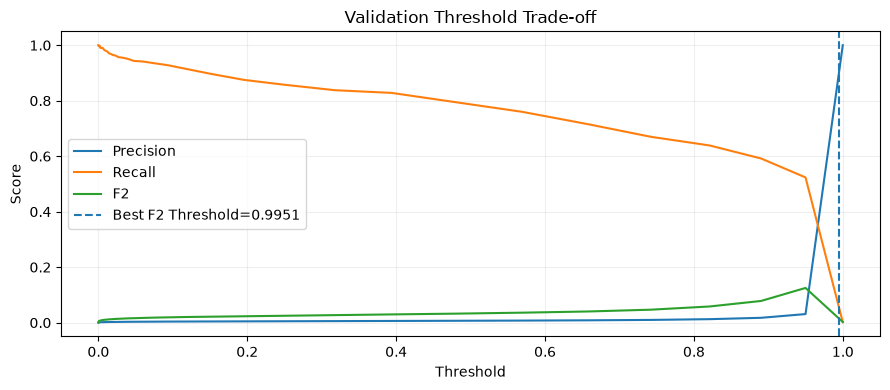

In [36]:
def best_f2_threshold(y_true, score):
    precision, recall, thresholds = precision_recall_curve(y_true, score)

    p = precision[:-1]
    r = recall[:-1]

    if len(thresholds) == 0:
        raise RuntimeError('Threshold를 계산할 수 없습니다.')

    f2 = (5 * p * r / (4 * p + r + 1e-12))

    table = pd.DataFrame({'threshold': thresholds, 'precision': p, 'recall': r, 'f2': f2,})

    idx = int(np.nanargmax(f2))

    return {'threshold': float(thresholds[idx]), 'precision': float(p[idx]), 'recall': float(r[idx]), 'f2': float(f2[idx]),}, table


valid_prob = best_model.predict_proba(X_valid)[:, 1]

ml_valid_result, ml_threshold_table = best_f2_threshold(y_valid, valid_prob)

ML_THRESHOLD = float(ml_valid_result['threshold'])

print('BEST_MODEL_NAME:', BEST_MODEL_NAME)
print('ML_THRESHOLD:', ML_THRESHOLD)
display(pd.DataFrame([ml_valid_result]))

plot_threshold = ml_threshold_table.copy()

if len(plot_threshold) > 500:
    plot_threshold = plot_threshold.iloc[np.linspace(0, len(plot_threshold) - 1, 500, dtype=int)]

plt.figure(figsize=(9, 4))
plt.plot(plot_threshold['threshold'], plot_threshold['precision'], label='Precision')
plt.plot(plot_threshold['threshold'], plot_threshold['recall'], label='Recall')
plt.plot(plot_threshold['threshold'], plot_threshold['f2'], label='F2')
plt.axvline(ML_THRESHOLD, linestyle='--', label=f'Best F2 Threshold={ML_THRESHOLD:.4f}')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Validation Threshold Trade-off')
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()


## 33. 최종 선택 모델의 Validation 결과 확인

Threshold까지 정한 뒤 Confusion Matrix, ROC Curve, Precision-Recall Curve를 확인합니다.

희소 Fraud에서는 ROC Curve만 보면 성능이 좋아 보일 수 있으므로 **PR Curve를 반드시 함께 확인**합니다.


              precision    recall  f1-score   support

           0     0.9999    0.9999    0.9999   4323464
           1     0.2438    0.3066    0.2716       512

    accuracy                         0.9998   4323976
   macro avg     0.6219    0.6533    0.6358   4323976
weighted avg     0.9998    0.9998    0.9998   4323976



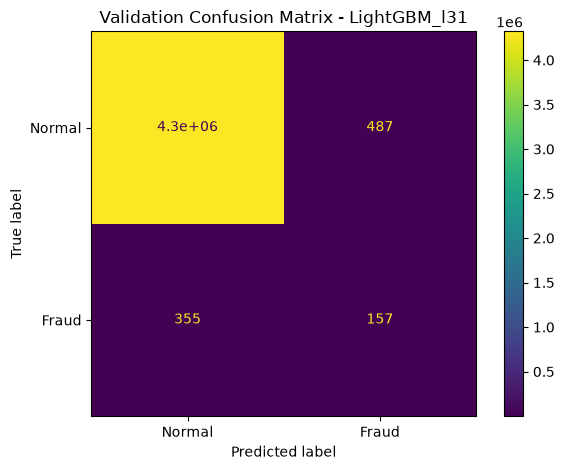

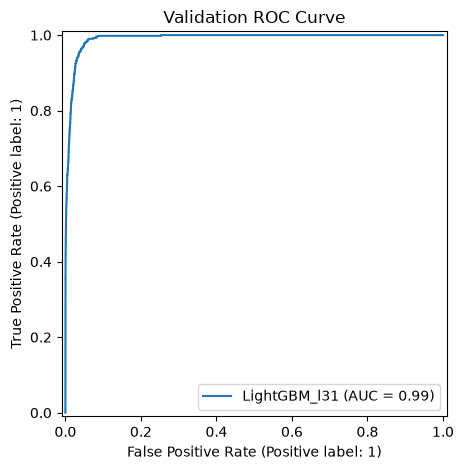

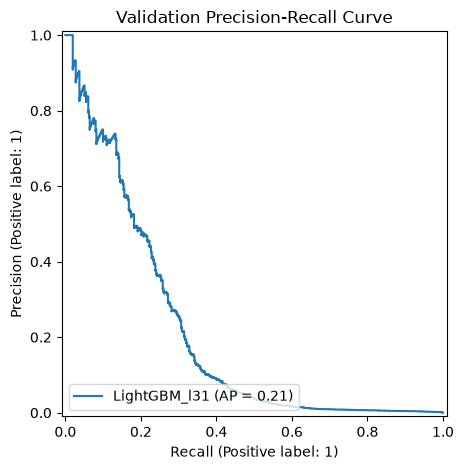

In [37]:
valid_pred = (valid_prob >= ML_THRESHOLD).astype(int)

print(classification_report(y_valid, valid_pred, digits=4, zero_division=0))

ConfusionMatrixDisplay.from_predictions(y_valid, valid_pred, display_labels=['Normal', 'Fraud'])
plt.title(f'Validation Confusion Matrix - {BEST_MODEL_NAME}')
plt.tight_layout()
plt.show()

RocCurveDisplay.from_predictions(y_valid, valid_prob, name=BEST_MODEL_NAME)
plt.title('Validation ROC Curve')
plt.tight_layout()
plt.show()

PrecisionRecallDisplay.from_predictions(y_valid, valid_prob, name=BEST_MODEL_NAME)
plt.title('Validation Precision-Recall Curve')
plt.tight_layout()
plt.show()


## 34. Feature Importance / Coefficient로 모델 해석

트리 계열 모델이면 `feature_importances_`, Logistic Regression이면 절댓값 계수를 사용해 어떤 Feature가 모델 판단에 크게 기여하는지 확인합니다.

> Importance가 높다고 해서 인과관계를 의미하지는 않습니다.


,feature,importance
0,num__amount_vs_merchant_avg,700.000000
1,num__device_age_days,612.000000
2,num__minutes_since_prev_event,523.000000
3,num__financial_assets_estimated,522.000000
4,num__credit_score,500.000000
5,num__amount_to_card_limit,430.000000
6,num__amount_to_monthly_card_budget,425.000000
7,num__amount_abs,408.000000
8,num__amount_vs_customer_mean_30d,407.000000
9,num__customer_event_count_1h,399.000000


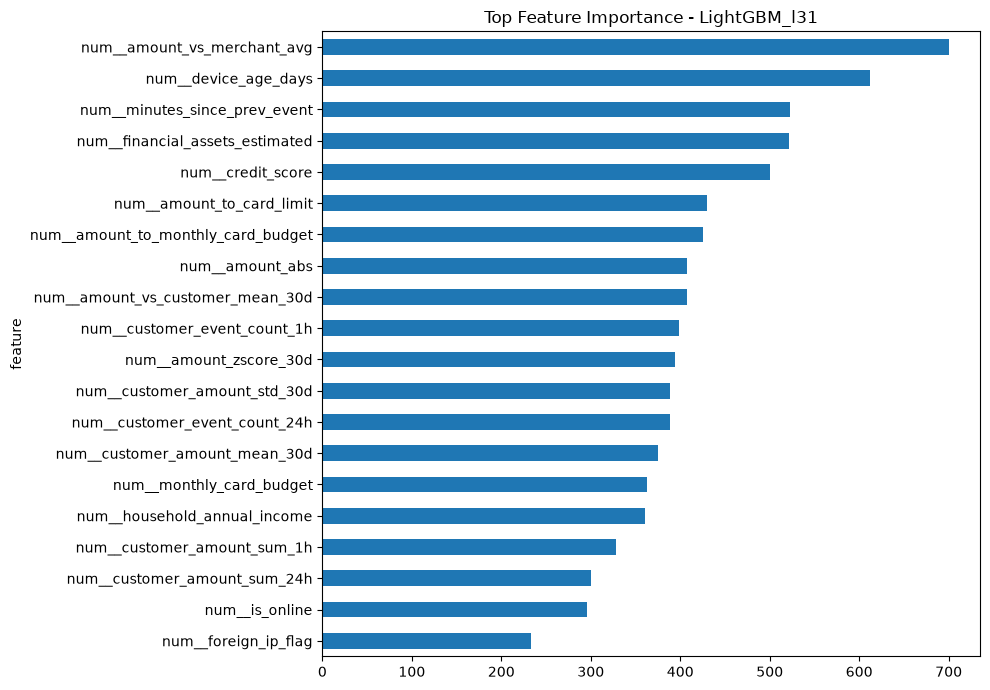

In [38]:
fitted_preprocess = (best_model.named_steps['preprocess'])

fitted_estimator = (best_model.named_steps['model'])

feature_names = (fitted_preprocess .get_feature_names_out())

importance = None

if hasattr(fitted_estimator, 'feature_importances_'):
    importance = np.asarray(fitted_estimator.feature_importances_, dtype=float)

elif hasattr(fitted_estimator, 'coef_'):
    coef = np.asarray(fitted_estimator.coef_, dtype=float)

    if coef.ndim == 2:
        coef = coef[0]

    importance = np.abs(coef)


if importance is not None:
    feature_importance = (pd.DataFrame({'feature': feature_names, 'importance': importance,}).sort_values('importance', ascending=False).reset_index(drop=True))

    display(feature_importance.head(20))

    ax = (feature_importance .head(20).sort_values('importance').plot(kind='barh', x='feature', y='importance', figsize=(10, 7), legend=False))

    ax.set_title(f'Top Feature Importance - {BEST_MODEL_NAME}')

    plt.tight_layout()
    plt.show()

else:
    print('이 모델은 공통 feature_importances_ / coef_ 속성을 제공하지 않습니다.')


## 35. Test 최종평가 — 여기서 처음 Test를 사용

모델 종류와 ML Threshold가 모두 Validation에서 결정되었습니다.

이제 Test를 사용해 미래 데이터에 가까운 최종 성능을 확인합니다.  
**Test 결과를 보고 다시 모델이나 Threshold를 조정하면 Test가 Validation처럼 사용되는 Leakage가 발생합니다.**


In [39]:
def evaluate_binary(y_true, prob, threshold):
    pred = (prob >= threshold).astype(int)
    return {'threshold':float(threshold),'alert_rate':float(pred.mean()), 'precision':precision_score(y_true,pred,zero_division=0), 'recall':recall_score(y_true,pred,zero_division=0), 'f1':f1_score(y_true,pred,zero_division=0), 'f2':fbeta_score(y_true,pred,beta=2,zero_division=0), 'roc_auc':roc_auc_score(y_true,prob),'pr_auc':average_precision_score(y_true,prob), 'tp':int(((pred==1)&(y_true==1)).sum()),'fp':int(((pred==1)&(y_true==0)).sum()), 'fn':int(((pred==0)&(y_true==1)).sum()),'tn':int(((pred==0)&(y_true==0)).sum()),}

test_prob = best_model.predict_proba(X_test)[:,1]
test_metrics = evaluate_binary(y_test,test_prob,ML_THRESHOLD)
display(pd.DataFrame([test_metrics]))
test_pred = (test_prob >= ML_THRESHOLD).astype(int)
print(classification_report(y_test,test_pred,digits=4,zero_division=0))
print(confusion_matrix(y_test,test_pred))

,threshold,alert_rate,precision,recall,f1,f2,roc_auc,pr_auc,tp,fp,fn,tn
0,0.995105,0.000122,0.281369,0.279773,0.280569,0.280091,0.990739,0.208080,148,378,381,4297156


              precision    recall  f1-score   support

           0     0.9999    0.9999    0.9999   4297534
           1     0.2814    0.2798    0.2806       529

    accuracy                         0.9998   4298063
   macro avg     0.6406    0.6398    0.6402   4298063
weighted avg     0.9998    0.9998    0.9998   4298063

[[4297156     378]
 [    381     148]]


## 36. 사기유형별 Recall

전체 Recall이 같아도 특정 Fraud 유형을 거의 못 잡을 수 있습니다.  
따라서 Test Fraud를 유형별로 나눠 탐지율을 확인합니다.


In [40]:
scored_test = test_df[['event_uid','event_at','source_table','event_subtype','customer_id', 'amount_abs','fraud_label','fraud_type','fraud_case_id','rule_score','rule_severity']].copy()
scored_test['ml_fraud_probability'] = test_prob
scored_test['ml_alert'] = test_pred
fraud_type_eval = (scored_test[scored_test['fraud_label'] == 1].groupby(['source_table','fraud_type'], as_index=False).agg(frauds=('fraud_label','size'),detected=('ml_alert','sum'),avg_probability=('ml_fraud_probability','mean')))
fraud_type_eval['recall'] = fraud_type_eval['detected'] / fraud_type_eval['frauds']
display(fraud_type_eval)

,source_table,fraud_type,frauds,detected,avg_probability,recall
0,card_payments,ACCOUNT_TAKEOVER,29,17,0.911742,0.586207
1,card_payments,CARD_NOT_PRESENT,293,113,0.804186,0.385666
2,card_payments,COUNTERFEIT_CARD,111,0,0.559759,0.000000
3,card_payments,LOST_STOLEN_CARD,77,0,0.646525,0.000000
4,transactions,INSTITUTION_IMPERSONATION,7,6,0.997932,0.857143
5,transactions,LOAN_IMPERSONATION,9,9,0.998951,1.000000
6,transactions,MESSENGER_PHISHING,3,3,0.999105,1.000000


## 37. Test ROC / PR Curve


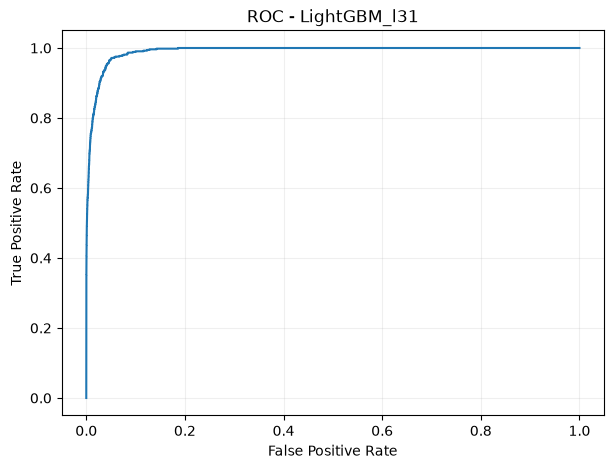

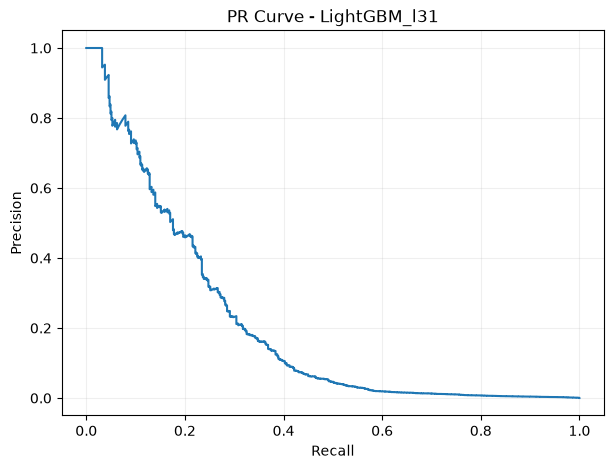

In [41]:
fpr,tpr,_ = roc_curve(y_test,test_prob)
p,r,_ = precision_recall_curve(y_test,test_prob)
plt.figure(figsize=(7,5)); plt.plot(fpr,tpr); plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate'); plt.title(f'ROC - {BEST_MODEL_NAME}'); plt.grid(alpha=.2); plt.show()
plt.figure(figsize=(7,5)); plt.plot(r,p); plt.xlabel('Recall'); plt.ylabel('Precision'); plt.title(f'PR Curve - {BEST_MODEL_NAME}'); plt.grid(alpha=.2); plt.show()

# Part 5. Rule + ML Hybrid 성능향상

ML만으로 끝내지 않고 Rule Engine과 ML Risk Score를 결합합니다.

- **Rule**: 명시적인 위험 패턴을 빠르게 탐지
- **ML**: 여러 Feature의 복합 패턴 탐지
- **Hybrid**: 두 방식의 장점을 결합

모든 Rule Threshold와 Hybrid Weight는 Validation에서만 결정하고 Test는 마지막 평가에만 사용합니다.


## 38. Validation에서 Rule Threshold 최종 선택

앞의 Rule Threshold 탐색은 Rule 동작을 이해하기 위한 탐색이었습니다.  
최종 Rule Threshold는 ML과 동일하게 **Validation 데이터만 사용**해 F2가 최대가 되는 지점으로 선택합니다.


In [42]:
valid_rule = (pd.to_numeric(valid_df['rule_score'], errors='coerce').fillna(0).clip(0, 100).to_numpy() / 100)

test_rule = (pd.to_numeric(test_df['rule_score'], errors='coerce').fillna(0).clip(0, 100).to_numpy() / 100)

rule_valid_result, rule_threshold_table = best_f2_threshold(y_valid, valid_rule)

RULE_THRESHOLD_NORMALIZED = float(rule_valid_result['threshold'])

RULE_THRESHOLD_SCORE = (RULE_THRESHOLD_NORMALIZED * 100)

print('Rule Validation:', rule_valid_result)

print('Final Rule Threshold (0~100):', f'{RULE_THRESHOLD_SCORE:.2f}')


Rule Validation: {'threshold': 0.5099999904632568, 'precision': 1.0, 'recall': 0.044921875, 'f2': 0.05552873008207222}
Final Rule Threshold (0~100): 51.00


## 39. Validation에서 Hybrid Weight와 Threshold 최종 선택

ML Risk Score와 Rule Score를 가중합합니다.

```text
Hybrid Score
= ML_WEIGHT × ML Risk Score
+ RULE_WEIGHT × Rule Score
```

가중치 후보를 Validation에서 비교하고, 각 조합마다 F2가 가장 높은 Threshold를 찾습니다.
Test 데이터는 이 과정에 사용하지 않습니다.

In [43]:
hybrid_rows = []

for ml_weight in np.arange(0.50, 0.91, 0.05):
    rule_weight = (1.0 - ml_weight)

    valid_hybrid_score = (ml_weight * valid_prob + rule_weight * valid_rule)

    threshold_result, _ = (best_f2_threshold(y_valid, valid_hybrid_score))

    hybrid_rows.append({'ml_weight': float(ml_weight), 'rule_weight': float(rule_weight), **threshold_result, 'pr_auc': average_precision_score(y_valid, valid_hybrid_score), 'roc_auc': roc_auc_score(y_valid, valid_hybrid_score),})

hybrid_search = (pd.DataFrame(hybrid_rows).sort_values(['f2', 'pr_auc', 'roc_auc',], ascending=False).reset_index(drop=True))

display(hybrid_search)

best_hybrid = (hybrid_search.iloc[0])

ML_WEIGHT = float(best_hybrid['ml_weight'])

RULE_WEIGHT = float(best_hybrid['rule_weight'])

HYBRID_THRESHOLD = float(best_hybrid['threshold'])

print('Final ML_WEIGHT:', ML_WEIGHT)
print('Final RULE_WEIGHT:', RULE_WEIGHT)
print('Final HYBRID_THRESHOLD:', HYBRID_THRESHOLD)

,ml_weight,rule_weight,threshold,precision,recall,f2,pr_auc,roc_auc
0,0.900000,0.100000,0.920787,0.156134,0.328125,0.268886,0.212623,0.988189
1,0.850000,0.150000,0.894043,0.287330,0.248047,0.255020,0.210225,0.987480
2,0.800000,0.200000,0.860276,0.287330,0.248047,0.255020,0.208653,0.986781
3,0.750000,0.250000,0.826509,0.287330,0.248047,0.255020,0.207463,0.986391
4,0.700000,0.300000,0.792741,0.287330,0.248047,0.255020,0.206520,0.985588
5,0.650000,0.350000,0.758974,0.287330,0.248047,0.255020,0.205723,0.985239
6,0.600000,0.400000,0.725207,0.287330,0.248047,0.255020,0.205047,0.984166
7,0.550000,0.450000,0.691440,0.287330,0.248047,0.255020,0.204421,0.983116
8,0.500000,0.500000,0.657672,0.287330,0.248047,0.255020,0.203810,0.981840


Final ML_WEIGHT: 0.9000000000000004
Final RULE_WEIGHT: 0.09999999999999964
Final HYBRID_THRESHOLD: 0.920786976511933


## 40. 보호조치 Action Threshold 확정

서비스에서는 단순히 Fraud/Normal만 반환하지 않고 위험도에 따라 보호조치를 나눕니다.

```text
PASS
STEP_UP_AUTH
TEMP_HOLD
BLOCK_AND_REVIEW
```

이 Threshold 역시 **Validation의 Hybrid Score만 사용**하여 정합니다.

In [44]:
valid_hybrid = (ML_WEIGHT * valid_prob + RULE_WEIGHT * valid_rule)

STEP_UP_THRESHOLD = max(0.05, HYBRID_THRESHOLD * 0.65)

TEMP_HOLD_THRESHOLD = (HYBRID_THRESHOLD)

fraud_scores_valid = (valid_hybrid[y_valid == 1])

if len(fraud_scores_valid):
    fraud_q75 = float(np.quantile(fraud_scores_valid, 0.75))
else:
    fraud_q75 = (TEMP_HOLD_THRESHOLD)

BLOCK_THRESHOLD = min(1.0, max(TEMP_HOLD_THRESHOLD, fraud_q75, TEMP_HOLD_THRESHOLD + 0.10))

FRAUD_ACTION_THRESHOLDS = {'step_up': float(STEP_UP_THRESHOLD), 'temporary_hold': float(TEMP_HOLD_THRESHOLD), 'block': float(BLOCK_THRESHOLD),}

display(pd.DataFrame(FRAUD_ACTION_THRESHOLDS.items(), columns=['action', 'threshold',]))

,action,threshold
0,step_up,0.598512
1,temporary_hold,0.920787
2,block,1.000000


## 41. Test에서 Rule / ML / Hybrid 최종평가

이제 모델, Threshold, Hybrid Weight가 모두 정해졌습니다.

**Test는 이 시점에 처음 최종평가 용도로 사용합니다.**
여기서 나온 결과를 보고 다시 Weight나 Threshold를 조정하지 않습니다.

In [45]:
def metric_row(name, y_true, score, threshold):
    pred = (score >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, pred, labels=[0, 1]).ravel()

    return {'method': name, 'threshold': float(threshold), 'total_events': int(len(y_true)), 'actual_fraud': int(tp + fn), 'actual_normal': int(tn + fp), 'predicted_fraud': int(tp + fp), 'predicted_normal': int(tn + fn), 'true_positive': int(tp), 'false_positive': int(fp), 'false_negative': int(fn), 'true_negative': int(tn), 'alert_rate': float(pred.mean()), 'precision': precision_score(y_true, pred, zero_division=0), 'recall': recall_score(y_true, pred, zero_division=0), 'f1': f1_score(y_true, pred, zero_division=0), 'f2': fbeta_score(y_true, pred, beta=2, zero_division=0), 'roc_auc': roc_auc_score(y_true, score), 'pr_auc': average_precision_score(y_true, score),}


test_hybrid = ML_WEIGHT * test_prob + RULE_WEIGHT * test_rule

final_comparison = pd.DataFrame([metric_row('Rule', y_test, test_rule, RULE_THRESHOLD_NORMALIZED), metric_row('ML', y_test, test_prob, ML_THRESHOLD), metric_row('Hybrid', y_test, test_hybrid, HYBRID_THRESHOLD),])

display(final_comparison)


,method,threshold,total_events,actual_fraud,actual_normal,predicted_fraud,predicted_normal,true_positive,false_positive,false_negative,true_negative,alert_rate,precision,recall,f1,f2,roc_auc,pr_auc
0,Rule,0.510000,4298063,529,4297534,19,4298044,19,0,510,4297534,0.000004,1.000000,0.035917,0.069343,0.044496,0.723177,0.036270
1,ML,0.995105,4298063,529,4297534,526,4297537,148,378,381,4297156,0.000122,0.281369,0.279773,0.280569,0.280091,0.990739,0.208080
2,Hybrid,0.920787,4298063,529,4297534,956,4297107,163,793,366,4296741,0.000222,0.170502,0.308129,0.219529,0.265299,0.982945,0.201433


## 42. Streamlit Serving Demo용 Sample 생성

서비스 화면에서는 전체 Test를 저장할 필요가 없습니다.

Fraud 유형별 대표 사례와 금액이 비슷한 정상거래를 일부만 골라
`fds_realtime_demo.csv.gz`를 만듭니다.

이 Demo의 Fraud 비율은 인위적으로 높기 때문에 **모델 성능평가에는 사용하지 않습니다.**

In [46]:
def decide_action(score):
    if score >= FRAUD_ACTION_THRESHOLDS['block']:
        return 'BLOCK_AND_REVIEW'
    if score >= FRAUD_ACTION_THRESHOLDS['temporary_hold']:
        return 'TEMP_HOLD'
    if score >= FRAUD_ACTION_THRESHOLDS['step_up']:
        return 'STEP_UP_AUTH'
    return 'PASS'


scored_test = test_df.copy()
scored_test['ml_risk_score'] = test_prob
scored_test['rule_probability'] = test_rule
scored_test['hybrid_score'] = test_hybrid
scored_test['hybrid_alert'] = (test_hybrid >= HYBRID_THRESHOLD).astype(int)
scored_test['protection_action'] = scored_test['hybrid_score'].map(decide_action)

# -----------------------------------------------------------------------------
# 최종 Test 전체 성능 요약
# Streamlit MVP에서 "실제 사기 vs Hybrid 검출"을 한눈에 비교하기 위한 작은 요약값입니다.
# 수백만 행 Test 전체를 앱으로 저장하지 않고, 정확한 집계 결과만 Metadata에 저장합니다.
# -----------------------------------------------------------------------------
hybrid_row = final_comparison.loc[final_comparison['method'].eq('Hybrid')].iloc[0].to_dict()

hybrid_test_summary = {**hybrid_row, 'test_start_time': str(scored_test['event_at'].min()), 'test_end_time': str(scored_test['event_at'].max()),}

source_rows = []
for source_name, group in scored_test.groupby('source_table', dropna=False):
    y = group['fraud_label'].astype(int).to_numpy()
    pred = group['hybrid_alert'].astype(int).to_numpy()
    tn, fp, fn, tp = confusion_matrix(y, pred, labels=[0, 1]).ravel()

    source_rows.append({'source_table': str(source_name), 'total_events': int(len(group)), 'actual_fraud': int(tp + fn), 'predicted_fraud': int(tp + fp), 'true_positive': int(tp), 'false_positive': int(fp), 'false_negative': int(fn), 'true_negative': int(tn), 'precision': float(tp / (tp + fp)) if (tp + fp) else 0.0, 'recall': float(tp / (tp + fn)) if (tp + fn) else 0.0, 'alert_rate': float((tp + fp) / len(group)) if len(group) else 0.0,})

hybrid_by_source = pd.DataFrame(source_rows)

fraud_only = scored_test.loc[scored_test['fraud_label'].eq(1)].copy()
hybrid_by_fraud_type = (fraud_only .groupby(['source_table', 'fraud_type'], dropna=False).agg(actual_fraud=('fraud_label', 'size'), detected_fraud=('hybrid_alert', 'sum'), avg_hybrid_score=('hybrid_score', 'mean')).reset_index())

hybrid_by_fraud_type['missed_fraud'] = hybrid_by_fraud_type['actual_fraud'] - hybrid_by_fraud_type['detected_fraud']
hybrid_by_fraud_type['recall'] = (hybrid_by_fraud_type['detected_fraud'] / hybrid_by_fraud_type['actual_fraud']).fillna(0)

display(pd.DataFrame([hybrid_test_summary]))
display(hybrid_by_source)
display(hybrid_by_fraud_type)

# -----------------------------------------------------------------------------
# Streamlit Serving Demo용 대표 Sample
# -----------------------------------------------------------------------------
fraud_demo = (scored_test[scored_test['fraud_label'].eq(1)].groupby(['source_table', 'fraud_type'], group_keys=False).head(10).copy())

normal_pool = scored_test[scored_test['fraud_label'].eq(0)].copy()

if len(normal_pool) > 50_000:
    normal_pool = normal_pool.sample(50_000, random_state=42)

matched = []

for row in fraud_demo.itertuples():
    pool = normal_pool[normal_pool['source_table'].eq(row.source_table)]
    if pool.empty:
        pool = normal_pool

    matched.append((pool['amount_abs'] - float(row.amount_abs)).abs().idxmin())

normal_demo = normal_pool.loc[list(dict.fromkeys(matched))].copy()

fraud_demo['demo_group'] = 'FRAUD'
normal_demo['demo_group'] = 'NORMAL_MATCH'

realtime_demo = pd.concat([fraud_demo, normal_demo], ignore_index=True).reset_index(drop=True)

display(realtime_demo[['demo_group', 'source_table', 'fraud_type', 'amount_abs', 'rule_score', 'ml_risk_score', 'hybrid_score', 'protection_action',]].head(50))


,method,threshold,total_events,actual_fraud,actual_normal,predicted_fraud,predicted_normal,true_positive,false_positive,false_negative,true_negative,alert_rate,precision,recall,f1,f2,roc_auc,pr_auc,test_start_time,test_end_time
0,Hybrid,0.920787,4298063,529,4297534,956,4297107,163,793,366,4296741,0.000222,0.170502,0.308129,0.219529,0.265299,0.982945,0.201433,2026-07-15 10:01:00,2026-09-13 22:59:00


,source_table,total_events,actual_fraud,predicted_fraud,true_positive,false_positive,false_negative,true_negative,precision,recall,alert_rate
0,card_payments,3417697,510,937,144,793,366,3416394,0.153682,0.282353,0.000274
1,transactions,880366,19,19,19,0,0,880347,1.000000,1.000000,0.000022


,source_table,fraud_type,actual_fraud,detected_fraud,avg_hybrid_score,missed_fraud,recall
0,card_payments,ACCOUNT_TAKEOVER,29,18,0.850844,11,0.620690
1,card_payments,CARD_NOT_PRESENT,293,126,0.752040,167,0.430034
2,card_payments,COUNTERFEIT_CARD,111,0,0.522161,111,0.000000
3,card_payments,LOST_STOLEN_CARD,77,0,0.599794,77,0.000000
4,transactions,INSTITUTION_IMPERSONATION,7,7,0.992996,0,1.000000
5,transactions,LOAN_IMPERSONATION,9,9,0.976389,0,1.000000
6,transactions,MESSENGER_PHISHING,3,3,0.960528,0,1.000000


,demo_group,source_table,fraud_type,amount_abs,rule_score,ml_risk_score,hybrid_score,protection_action
0,FRAUD,card_payments,CARD_NOT_PRESENT,"897,897.900000",32.000000,0.999904,0.931914,TEMP_HOLD
1,FRAUD,card_payments,COUNTERFEIT_CARD,"707,807.670000",20.000000,0.930604,0.857543,STEP_UP_AUTH
2,FRAUD,card_payments,CARD_NOT_PRESENT,"147,294.220000",12.000000,0.996108,0.908497,STEP_UP_AUTH
3,FRAUD,card_payments,CARD_NOT_PRESENT,"127,143.670000",32.000000,0.995389,0.927850,TEMP_HOLD
4,FRAUD,card_payments,COUNTERFEIT_CARD,"256,532.500000",10.000000,0.928180,0.845362,STEP_UP_AUTH
5,FRAUD,card_payments,LOST_STOLEN_CARD,"519,533.660000",10.000000,0.990711,0.901640,STEP_UP_AUTH
6,FRAUD,card_payments,LOST_STOLEN_CARD,"359,295.490000",20.000000,0.982746,0.904472,STEP_UP_AUTH
7,FRAUD,card_payments,CARD_NOT_PRESENT,"101,992.620000",32.000000,0.966505,0.901854,STEP_UP_AUTH
8,FRAUD,card_payments,COUNTERFEIT_CARD,"227,272.800000",20.000000,0.733491,0.680142,STEP_UP_AUTH
9,FRAUD,card_payments,LOST_STOLEN_CARD,"82,174.090000",20.000000,0.546183,0.511565,PASS


## 43. 최종 Model Serving Artifact 저장

여기부터는 모델 개발이 끝난 상태입니다.

04 Serving에서 필요한 것은 다음뿐입니다.

```text
models/
├─ fds_model.joblib
├─ fds_model_metadata.json
├─ fds_hybrid_metadata.json
├─ fds_rule_config.json
└─ fds_model.sha256

output/
└─ fds_realtime_demo.csv.gz

프로젝트 루트/
└─ requirements.streamlit.txt  ← 학습 환경 버전으로 자동 생성
```

In [47]:
MODEL_PATH = (MODEL_DIR / 'fds_model.joblib')

MODEL_META_PATH = (MODEL_DIR / 'fds_model_metadata.json')

HYBRID_META_PATH = (MODEL_DIR / 'fds_hybrid_metadata.json')

RULE_CONFIG_PATH = (MODEL_DIR / 'fds_rule_config.json')

MODEL_HASH_PATH = (MODEL_DIR / 'fds_model.sha256')

REALTIME_DATA_PATH = (OUTPUT_DIR / 'fds_realtime_demo.csv.gz')
SERVING_REQUIREMENTS_PATH = (PROJECT_DIR / 'requirements.streamlit.txt')


# -------------------------------------------------------------------------
# 최종 ML 모델
# -------------------------------------------------------------------------
joblib.dump(best_model, MODEL_PATH)


# -------------------------------------------------------------------------
# Runtime Version
# -------------------------------------------------------------------------
runtime_versions = {'python': platform.python_version(), 'pandas': pd.__version__, 'numpy': np.__version__, 'scikit_learn': sklearn.__version__, 'joblib': joblib.__version__,}

try:
    import xgboost

    runtime_versions['xgboost'] = xgboost.__version__

except Exception:
    runtime_versions['xgboost'] = None

try:
    import lightgbm

    runtime_versions['lightgbm'] = lightgbm.__version__

except Exception:
    runtime_versions['lightgbm'] = None


# -------------------------------------------------------------------------
# Docker/Streamlit Serving 환경 버전 고정
# 모델을 만든 환경과 Serving 환경의 핵심 라이브러리 버전을 맞춥니다.
# -------------------------------------------------------------------------
requirements_lines = ['streamlit>=1.40,<2', f'pandas=={runtime_versions["pandas"]}', f'numpy=={runtime_versions["numpy"]}', f'scikit-learn=={runtime_versions["scikit_learn"]}', f'joblib=={runtime_versions["joblib"]}']
if runtime_versions.get('xgboost'): requirements_lines.append(f'xgboost=={runtime_versions["xgboost"]}')
if runtime_versions.get('lightgbm'): requirements_lines.append(f'lightgbm=={runtime_versions["lightgbm"]}')
SERVING_REQUIREMENTS_PATH.write_text('\n'.join(requirements_lines) + '\n', encoding='utf-8')


# -------------------------------------------------------------------------
# ML Metadata
# -------------------------------------------------------------------------
ml_metadata = {'pipeline': 'integrated_01_02_03_model_development', 'source_schema': SCHEMA, 'lookback_months': LOOKBACK_MONTHS, 'as_of_date': str(AS_OF_DATE), 'model_name': BEST_MODEL_NAME, 'model_features': MODEL_FEATURES, 'numeric_features': NUMERIC_FEATURES, 'categorical_features': CATEGORICAL_FEATURES, 'ml_threshold': ML_THRESHOLD, 'training_negative_positive_ratio': NEG_POS_RATIO, 'train_original_fraud_rate': float(train_df['fraud_label'].mean()), 'train_fit_fraud_rate': float(train_fit_df['fraud_label'].mean()), 'validation_fraud_rate': float(valid_df['fraud_label'].mean()), 'test_fraud_rate': float(test_df['fraud_label'].mean()), 'train_end_time': str(TRAIN_END_TIME), 'valid_end_time': str(VALID_END_TIME), 'split_method': ('strict event_at boundary ' 'around 60/80 percent row targets'), 'validation_model_comparison': model_comparison.to_dict(orient='records'), 'validation_ml_threshold_result': ml_valid_result, 'ml_test_metrics': test_metrics, 'runtime_versions': runtime_versions, 'serving_requirements_file': SERVING_REQUIREMENTS_PATH.name, 'probability_note': ('predict_proba는 calibration된 실제 사기확률보다 ' 'ML Risk Score로 해석'),}


# -------------------------------------------------------------------------
# Hybrid Metadata
# -------------------------------------------------------------------------
hybrid_metadata = {'rule_threshold_normalized': RULE_THRESHOLD_NORMALIZED, 'rule_threshold_score_100': RULE_THRESHOLD_SCORE, 'ml_weight': ML_WEIGHT, 'rule_weight': RULE_WEIGHT, 'ml_threshold': ML_THRESHOLD, 'hybrid_threshold': HYBRID_THRESHOLD, 'fraud_action_thresholds': FRAUD_ACTION_THRESHOLDS, 'selection_data': 'Validation only', 'test_usage': 'Final evaluation only', 'validation_rule_result': rule_valid_result, 'validation_best_hybrid': best_hybrid.to_dict(), 'test_comparison': final_comparison.to_dict(orient='records'), 'test_summary': hybrid_test_summary, 'test_by_source': hybrid_by_source.to_dict(orient='records'), 'test_by_fraud_type': hybrid_by_fraud_type.to_dict(orient='records'), 'serving_note': ('04에서는 모든 threshold/weight를 ' '재튜닝하지 않고 그대로 로드'),}


# -------------------------------------------------------------------------
# Rule Config
# -------------------------------------------------------------------------
rule_metadata = {'rule_config': RULE_CONFIG, 'rule_weights': RULE_WEIGHTS, 'rule_score_max': 100, 'exploratory_rule_threshold': EXPLORATORY_RULE_THRESHOLD, 'final_rule_threshold': RULE_THRESHOLD_SCORE,}


with open(MODEL_META_PATH, 'w', encoding='utf-8') as f:
    json.dump(ml_metadata, f, ensure_ascii=False, indent=2, default=str)

with open(HYBRID_META_PATH, 'w', encoding='utf-8') as f:
    json.dump(hybrid_metadata, f, ensure_ascii=False, indent=2, default=str)

with open(RULE_CONFIG_PATH, 'w', encoding='utf-8') as f:
    json.dump(rule_metadata, f, ensure_ascii=False, indent=2, default=str)


# -------------------------------------------------------------------------
# Streamlit Demo Data
# -------------------------------------------------------------------------
realtime_demo.to_csv(REALTIME_DATA_PATH, index=False, compression='gzip')


# -------------------------------------------------------------------------
# Model SHA256
# -------------------------------------------------------------------------
sha256 = hashlib.sha256(MODEL_PATH.read_bytes()).hexdigest()

MODEL_HASH_PATH.write_text(sha256, encoding='utf-8')


print('saved:', MODEL_PATH)
print('saved:', MODEL_META_PATH)
print('saved:', HYBRID_META_PATH)
print('saved:', RULE_CONFIG_PATH)
print('saved:', MODEL_HASH_PATH)
print('saved:', REALTIME_DATA_PATH)
print('saved:', SERVING_REQUIREMENTS_PATH)
print()
print('Model development completed.')
print('다음 단계: 04 Model Serving')

saved: D:\AI캠퍼스 강의안\fintech_AI_Campus_lecture_note\03_AI_Core_머신러닝\01_FDS_사기탐지모델개발 및 MVP\models\fds_model.joblib
saved: D:\AI캠퍼스 강의안\fintech_AI_Campus_lecture_note\03_AI_Core_머신러닝\01_FDS_사기탐지모델개발 및 MVP\models\fds_model_metadata.json
saved: D:\AI캠퍼스 강의안\fintech_AI_Campus_lecture_note\03_AI_Core_머신러닝\01_FDS_사기탐지모델개발 및 MVP\models\fds_hybrid_metadata.json
saved: D:\AI캠퍼스 강의안\fintech_AI_Campus_lecture_note\03_AI_Core_머신러닝\01_FDS_사기탐지모델개발 및 MVP\models\fds_rule_config.json
saved: D:\AI캠퍼스 강의안\fintech_AI_Campus_lecture_note\03_AI_Core_머신러닝\01_FDS_사기탐지모델개발 및 MVP\models\fds_model.sha256
saved: D:\AI캠퍼스 강의안\fintech_AI_Campus_lecture_note\03_AI_Core_머신러닝\01_FDS_사기탐지모델개발 및 MVP\output\fds_realtime_demo.csv.gz
saved: D:\AI캠퍼스 강의안\fintech_AI_Campus_lecture_note\03_AI_Core_머신러닝\01_FDS_사기탐지모델개발 및 MVP\requirements.streamlit.txt

Model development completed.
다음 단계: 04 Model Serving


# 모델 개발 완료

이제 FDS 모델 개발의 전체 흐름이 하나의 Notebook에서 연결되었습니다.

```text
DB에서 원천 데이터 조회
→ Event 통합 / Data Contract
→ EDA
→ Point-in-Time Feature Engineering
→ Rule Baseline
→ 시간순 Train / Validation / Test
→ Logistic / RandomForest Baseline
→ Class Weight로 불균형 대응
→ XGBoost / LightGBM 포함 경량 HPO
→ Validation PR-AUC로 최종 모델 선택
→ Validation F2로 ML Threshold 조정
→ Rule Threshold 조정
→ ML + Rule Hybrid Weight / Threshold 조정
→ Test 최종평가
→ 모델 / Metadata / Demo Data / Serving requirements 저장
```

### 핵심 원칙

1. **EDA를 먼저 하고 모델을 만든다.**
2. **미래 정보를 Feature에 사용하지 않는다.**
3. **Fraud 희소성 때문에 Accuracy만 보지 않는다.**
4. **모델 선택은 PR-AUC, 운영 Threshold는 F2를 중심으로 본다.**
5. **Test는 마지막 한 번의 최종평가에만 사용한다.**
6. **서비스에서는 저장된 Pipeline과 Threshold를 그대로 사용한다.**

7. **Docker/Streamlit은 03이 생성한 `requirements.streamlit.txt`를 사용해 학습 환경과 핵심 라이브러리 버전을 맞춘다.**
